# MVP — Risco, Custo e Tempo de Implantação de uma Nova Unidade de Armazenamento em Nuvem

**Aluno(a):** _Matheus Victor Costa Cabral_
**Matrícula:** _221021035_
**Disciplina:** Sistemas de Suporte à Decisão (SSD)

---

## Problema de decisão

Uma empresa de controle de dados e armazenamento em nuvem vai abrir uma **nova unidade (data center)** com meta de **5 PB de capacidade útil**. A decisão central é: **qual modelo de disco rígido deve compor essa unidade?**

A escolha do modelo de disco não é trivial porque ela amarra, de uma só vez, as três dimensões clássicas de um projeto de infraestrutura:

| Dimensão | O que significa aqui | Como é medida neste MVP |
|---|---|---|
| **Risco** | Probabilidade de o disco falhar em operação, o que significa reconstrução de dados, janela de vulnerabilidade e trabalho não planejado | **Dados reais**: taxa de falha anualizada (AFR) observada + modelo de *machine learning* treinado sobre atributos S.M.A.R.T. reais |
| **Custo** | CapEx de aquisição + OpEx de reposição de discos falhados + energia, ao longo de 5 anos | **Modelo heurístico explícito**, alimentado pelo risco real medido |
| **Tempo** | Semanas entre a decisão de compra e a unidade entrar em produção | **Modelo heurístico explícito**, ajustado pelo risco real medido |

As três dimensões são então combinadas em uma **Matriz de Decisão Multicritério (MCDA)**, submetida a **análise de sensibilidade dos pesos** e a uma **simulação de Monte Carlo**, para produzir uma recomendação que não dependa de um único conjunto arbitrário de premissas.

## Base de dados

Usamos o **Backblaze Hard Drive Stats** — a base operacional pública da Backblaze, empresa real de backup e armazenamento em nuvem que publica, desde 2013, um *snapshot* diário de **todos os discos rígidos dos seus data centers**. Cada linha é *um disco em um dia*, e contém:

- `date`, `serial_number`, `model`, `capacity_bytes`
- `failure` — vale `1` **apenas no dia em que o disco falhou** e foi removido, `0` nos demais dias
- dezenas de atributos **S.M.A.R.T.** (`smart_X_normalized` / `smart_X_raw`), a telemetria de saúde reportada pelo próprio firmware do disco

Neste MVP é analisado o **1º trimestre de 2016 completo** (~57 mil discos por dia, ~5,1 milhões de registros disco-dia).

> **Por que essa base é boa para um SSD?** Porque o eixo de Risco deixa de ser um score inventado e passa a ser **uma taxa de falha efetivamente observada em campo**, com incerteza estatística quantificável. É a diferença entre "eu acho que este disco é arriscado" e "este modelo falhou N vezes em M disco-dias".

## 1. Configuração do Ambiente

In [1]:
import warnings, io, math, time, urllib.request, urllib.error, os, textwrap
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             classification_report, average_precision_score)
from scipy import stats

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['font.size'] = 9
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('pandas     ', pd.__version__)
print('numpy      ', np.__version__)
import sklearn; print('scikit-learn', sklearn.__version__)
print('\nAmbiente configurado com sucesso.')

pandas      3.0.2
numpy       2.4.4
scikit-learn 1.8.0

Ambiente configurado com sucesso.


## 2. Origem e Aquisição da Base Real

Os arquivos diários da Backblaze são distribuídos oficialmente em <https://www.backblaze.com/cloud-storage/resources/hard-drive-test-data> e espelhados no Kaggle (*Backblaze Hard Drive Stats*). Neste notebook eles são lidos de um **espelho público no GitHub** dos mesmos arquivos CSV diários — isso torna o notebook **100% auto-suficiente no Colab**: não é preciso credencial do Kaggle, `kaggle.json`, nem upload manual de arquivo.

> ⚠️ **Cuidado importante com esta base.** O *preview*/export do Kaggle às vezes entrega um arquivo **apenas com o cabeçalho** (zero linhas de dado). Um snapshot diário real da Backblaze em 2016 tem **~57 mil linhas** — uma por disco vivo naquele dia. Por isso a célula abaixo faz uma **verificação de sanidade obrigatória** antes de qualquer análise: se o arquivo vier com menos de 1.000 linhas, ele é descartado e registrado como dia inválido, em vez de contaminar silenciosamente a estatística.

In [2]:
# ---------------------------------------------------------------------------
# PARÂMETROS DA COLETA
# ---------------------------------------------------------------------------
BASE_URL     = 'https://raw.githubusercontent.com/Alifoam/Hard-Drive-Disk-Stats/main/2014_Q1/'
DATA_INICIO  = '2016-01-01'
DATA_FIM     = '2016-03-31'      # 1o trimestre de 2016 completo
MIN_LINHAS   = 1_000             # sanidade: abaixo disso o arquivo e' considerado invalido
JANELA_PRE_FALHA = 7             # dias antes da falha rotulados como "pre-falha" (alvo do ML)
AMOSTRA_SAUDAVEIS_DIA = 800      # discos saudaveis amostrados por dia para o dataset de ML

# Atributos S.M.A.R.T. presentes em 100% dos discos da base (independem do fabricante)
SMART_IDS = [1, 3, 4, 5, 7, 9, 10, 12, 192, 193, 194, 197, 198, 199]
SMART_COLS = [f'smart_{i}_{k}' for i in SMART_IDS for k in ('normalized', 'raw')]
COLS_USADAS = ['date', 'serial_number', 'model', 'capacity_bytes', 'failure'] + SMART_COLS

DIAS = [d.strftime('%Y-%m-%d') for d in pd.date_range(DATA_INICIO, DATA_FIM)]
print(f'Periodo solicitado : {DATA_INICIO} a {DATA_FIM}  ({len(DIAS)} dias)')
print(f'Colunas requisitadas: {len(COLS_USADAS)} (5 identificadoras + {len(SMART_COLS)} S.M.A.R.T.)')

Periodo solicitado : 2016-01-01 a 2016-03-31  (91 dias)
Colunas requisitadas: 33 (5 identificadoras + 28 S.M.A.R.T.)


In [3]:
# ---------------------------------------------------------------------------
# TESTE DE SANIDADE: baixa UM dia e confere se o arquivo tem volume real
# ---------------------------------------------------------------------------
def baixar_dia(dia, timeout=90):
    '''Baixa o CSV de um dia. Retorna None se o dia nao existe no espelho.'''
    try:
        with urllib.request.urlopen(f'{BASE_URL}{dia}.csv', timeout=timeout) as r:
            return r.read()
    except urllib.error.HTTPError:
        return None

_amostra = baixar_dia('2016-01-02')
_df_teste = pd.read_csv(io.BytesIO(_amostra), usecols=lambda c: c in COLS_USADAS)

print(f'Arquivo 2016-01-02.csv .......... {len(_amostra)/1e6:.1f} MB')
print(f'Linhas (discos monitorados) ..... {len(_df_teste):,}')
print(f'Colunas lidas ................... {_df_teste.shape[1]}')
print(f'Discos que falharam nesse dia ... {int(_df_teste.failure.sum())}')
print()
if len(_df_teste) >= MIN_LINHAS:
    print('OK -> volume compativel com um snapshot diario real da Backblaze.')
else:
    raise RuntimeError('Arquivo veio vazio/truncado - trocar de espelho antes de prosseguir.')
print()
display(_df_teste.head(3))

Arquivo 2016-01-02.csv .......... 15.0 MB
Linhas (discos monitorados) ..... 57,545
Colunas lidas ................... 33
Discos que falharam nesse dia ... 6

OK -> volume compativel com um snapshot diario real da Backblaze.



,date,serial_number,model,capacity_bytes,failure,smart_1_normalized,smart_1_raw,smart_3_normalized,smart_3_raw,smart_4_normalized,smart_4_raw,smart_5_normalized,smart_5_raw,smart_7_normalized,smart_7_raw,smart_9_normalized,smart_9_raw,smart_10_normalized,smart_10_raw,smart_12_normalized,smart_12_raw,smart_192_normalized,smart_192_raw,smart_193_normalized,smart_193_raw,smart_194_normalized,smart_194_raw,smart_197_normalized,smart_197_raw,smart_198_normalized,smart_198_raw,smart_199_normalized,smart_199_raw
0,2016-01-02,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,3000592982016,0,100,0,143,540,100,14,100,0,100,0,97,27953,100,0,100,14,100.0,217.0,100.0,217.0,253.0,20.0,100,0,100,0,200,0
1,2016-01-02,Z305B2QN,ST4000DM000,4000787030016,0,113,54551400,96,0,100,4,100,0,63,2591946,100,435,100,0,100,4,100.0,0.0,92.0,17508.0,30.0,30.0,100,0,100,0,200,0
2,2016-01-02,MJ0351YNG9Z7LA,Hitachi HDS5C3030ALA630,3000592982016,0,100,0,124,566,100,19,100,0,100,0,97,27516,100,0,100,18,100.0,213.0,100.0,213.0,250.0,24.0,100,0,100,0,200,0


**Leitura:** o arquivo baixado tem volume compatível com a operação real da Backblaze em 2016 — dezenas de milhares de discos monitorados em um único dia, com um punhado de falhas. Isso confirma que **não** estamos diante do problema de export vazio do Kaggle e que a base pode ser usada com segurança.

Repare já aqui na natureza do problema: falha de disco é um **evento raro**. Isso vai reaparecer como forte desbalanceamento de classes na modelagem de risco, e é exatamente por isso que a acurácia bruta será uma métrica inútil mais adiante.

## 3. Ingestão e Consolidação do Trimestre

A base bruta do trimestre tem ~5 milhões de linhas — grande demais para carregar inteira na memória do Colab. A estratégia é **varrer dia a dia e consolidar na passagem**, guardando apenas o que cada análise precisa:

1. **Agregado por modelo** — total de *disco-dias* e total de falhas (insumo do AFR real).
2. **Série diária** — nº de discos ativos e nº de falhas por dia.
3. **Dataset de Machine Learning** — registros rotulados para treinar o classificador.

> **Detalhe metodológico (por que a varredura é de trás para frente).** Para prever falha, não basta usar a linha do dia da falha: queremos os sinais S.M.A.R.T. **nos dias que antecedem** a falha. Mas ao ler cronologicamente só descobrimos que um disco falhou *depois* de já ter passado pelos dias anteriores dele. Varrendo o trimestre **em ordem cronológica inversa** (31/03 → 01/01), quando encontramos uma falha já podemos capturar os registros dos dias anteriores daquele mesmo `serial_number` — que, na ordem invertida, ainda estão por vir. Assim rotulamos a **janela de 7 dias pré-falha** em uma única passagem, sem baixar a base duas vezes.

In [4]:
# ---------------------------------------------------------------------------
# VARREDURA DO TRIMESTRE (ordem cronologica INVERSA)
# ---------------------------------------------------------------------------
agregado   = {}    # (model, capacity_bytes) -> [disco_dias, falhas]
serie_dia  = []    # metricas diarias
buf_pos    = []    # registros na janela pre-falha  (classe 1)
buf_neg    = []    # amostra de discos saudaveis    (classe 0)
falha_em   = {}    # serial_number -> data da falha
dias_ok, dias_ausentes, dias_invalidos = [], [], []

t0 = time.time()
for i, dia in enumerate(DIAS[::-1], 1):
    bruto = baixar_dia(dia)
    if bruto is None:
        dias_ausentes.append(dia); continue

    df = pd.read_csv(io.BytesIO(bruto), usecols=lambda c: c in COLS_USADAS)

    if len(df) < MIN_LINHAS:                      # <-- guarda contra arquivo vazio/truncado
        dias_invalidos.append(dia); continue

    # (1) agregado por modelo
    g = df.groupby(['model', 'capacity_bytes']).agg(dd=('failure', 'size'), f=('failure', 'sum'))
    for chave, linha in g.iterrows():
        acc = agregado.setdefault(chave, [0, 0])
        acc[0] += int(linha.dd); acc[1] += int(linha.f)

    # (2) serie diaria
    serie_dia.append({'date': pd.Timestamp(dia), 'discos_ativos': len(df),
                      'falhas': int(df.failure.sum())})

    # (3) dataset de ML -----------------------------------------------------
    hoje = pd.Timestamp(dia)
    for s in df.loc[df.failure == 1, 'serial_number']:
        falha_em.setdefault(s, hoje)

    if falha_em:                                   # registros na janela pre-falha
        mapeado = pd.to_datetime(df.serial_number.map(falha_em))
        dias_ate = (mapeado - hoje).dt.days
        sel = df[(dias_ate >= 0) & (dias_ate <= JANELA_PRE_FALHA)]
        if len(sel):
            buf_pos.append(sel.assign(dias_ate_falha=dias_ate[sel.index]))

    saud = df.loc[df.failure == 0]                 # amostra de saudaveis
    buf_neg.append(saud.sample(n=min(AMOSTRA_SAUDAVEIS_DIA, len(saud)),
                               random_state=RANDOM_STATE))

    dias_ok.append(dia)
    if i % 15 == 0 or i == len(DIAS):
        print(f'  [{i:3d}/{len(DIAS)}] {dia} | {len(df):,} discos | '
              f'{int(df.failure.sum())} falhas | {time.time()-t0:5.0f}s')

print('\n' + '=' * 72)
print(f'Dias processados com sucesso : {len(dias_ok)}')
print(f'Dias ausentes no espelho     : {len(dias_ausentes)}  {dias_ausentes}')
print(f'Dias descartados por volume  : {len(dias_invalidos)}  {dias_invalidos}')
print(f'Tempo total de ingestao      : {time.time()-t0:.0f} s')
print('=' * 72)

  [ 15/91] 2016-03-17 | 62,231 discos | 4 falhas |    10s


  [ 30/91] 2016-03-02 | 62,415 discos | 4 falhas |    19s


  [ 45/91] 2016-02-16 | 59,217 discos | 5 falhas |    28s


  [ 60/91] 2016-02-01 | 58,297 discos | 7 falhas |    37s


  [ 75/91] 2016-01-17 | 57,514 discos | 7 falhas |    46s


  [ 90/91] 2016-01-02 | 57,545 discos | 6 falhas |    53s


  [ 91/91] 2016-01-01 | 57,545 discos | 4 falhas |    54s

Dias processados com sucesso : 89
Dias ausentes no espelho     : 2  ['2016-01-05', '2016-01-04']
Dias descartados por volume  : 0  []
Tempo total de ingestao      : 54 s


In [5]:
# ---------------------------------------------------------------------------
# MONTAGEM DAS TRES TABELAS DE TRABALHO
# ---------------------------------------------------------------------------
# (A) serie temporal diaria
df_dias = pd.DataFrame(serie_dia).sort_values('date').reset_index(drop=True)

# (B) agregado por modelo de disco
df_modelos = (pd.DataFrame([{'model': k[0], 'capacity_bytes': k[1],
                             'disco_dias': v[0], 'falhas': v[1]}
                            for k, v in agregado.items()]))

# a coluna capacity_bytes tem valores corrompidos conhecidos (negativos/absurdos)
# faixa plausivel: nenhum disco de data center abaixo de 0,4 TB ou acima de 25 TB em 2016
df_modelos = df_modelos[(df_modelos.capacity_bytes > 4e11) &
                        (df_modelos.capacity_bytes < 25e12)]
df_modelos['capacidade_tb'] = (df_modelos.capacity_bytes / 1e12).round(2)
# um modelo pode aparecer com mais de um valor de capacidade (registros corrompidos):
# consolidamos por modelo e adotamos a capacidade da variante com mais disco-dias
df_modelos = df_modelos.sort_values('disco_dias', ascending=False)
df_modelos = (df_modelos.groupby('model', as_index=False)
              .agg(capacidade_tb=('capacidade_tb', 'first'),
                   disco_dias=('disco_dias', 'sum'),
                   falhas=('falhas', 'sum')))

# (C) dataset rotulado para Machine Learning
pos = pd.concat(buf_pos, ignore_index=True).drop_duplicates(subset=['date', 'serial_number'])
neg = pd.concat(buf_neg, ignore_index=True)
neg = neg[~neg.serial_number.isin(set(pos.serial_number))]     # evita vazamento de rotulo
pos['alvo'] = 1
neg['alvo'] = 0
neg['dias_ate_falha'] = np.nan
df_ml = pd.concat([pos, neg], ignore_index=True)

print(f'(A) df_dias    : {df_dias.shape[0]} dias                -> serie temporal')
print(f'(B) df_modelos : {df_modelos.shape[0]} modelos de disco -> AFR real')
print(f'(C) df_ml      : {df_ml.shape[0]:,} registros rotulados -> classificador')
print(f'      classe 1 (pre-falha, ate {JANELA_PRE_FALHA} dias antes): {int(df_ml.alvo.sum()):,}'
      f'  ({100*df_ml.alvo.mean():.2f}%)')
print(f'      classe 0 (saudaveis)                          : {int((df_ml.alvo==0).sum()):,}')
print()
print(f'Total de disco-dias no trimestre : {df_modelos.disco_dias.sum():,}')
print(f'Total de falhas no trimestre     : {df_modelos.falhas.sum():,}')

(A) df_dias    : 89 dias                -> serie temporal
(B) df_modelos : 42 modelos de disco -> AFR real
(C) df_ml      : 73,440 registros rotulados -> classificador
      classe 1 (pre-falha, ate 7 dias antes): 2,430  (3.31%)
      classe 0 (saudaveis)                          : 71,010

Total de disco-dias no trimestre : 5,314,565
Total de falhas no trimestre     : 278


## 4. Qualidade dos Dados

In [6]:
print('>>> ESTRUTURA E TIPOS (amostra de colunas do dataset de ML)')
print(df_ml[['date', 'serial_number', 'model', 'capacity_bytes', 'failure',
             'smart_5_raw', 'smart_9_raw', 'smart_197_raw', 'alvo']].dtypes.to_string())

print('\n>>> VALORES AUSENTES nas features S.M.A.R.T. (% do dataset de ML)')
faltantes = (df_ml[SMART_COLS].isna().mean() * 100).sort_values(ascending=False)
print(faltantes[faltantes > 0].round(2).to_string() if (faltantes > 0).any()
      else '  Nenhum valor ausente nas colunas S.M.A.R.T. selecionadas.')

print('\n>>> DUPLICATAS (mesmo disco no mesmo dia):', df_ml.duplicated(subset=['date','serial_number']).sum())

print('\n>>> CATEGORIAS')
print(f'  Modelos distintos de disco no trimestre : {df_modelos.model.nunique()}')
print('  Capacidades distintas (TB)              : '
      + ', '.join(f'{c:g}' for c in sorted(df_modelos.capacidade_tb.unique())))

>>> ESTRUTURA E TIPOS (amostra de colunas do dataset de ML)
date                  str
serial_number         str
model                 str
capacity_bytes      int64
failure             int64
smart_5_raw       float64
smart_9_raw       float64
smart_197_raw     float64
alvo                int64

>>> VALORES AUSENTES nas features S.M.A.R.T. (% do dataset de ML)
smart_193_raw           1.35
smart_193_normalized    1.35
smart_192_raw           0.39
smart_192_normalized    0.39
smart_4_normalized      0.00
smart_4_raw             0.00
smart_5_normalized      0.00
smart_5_raw             0.00
smart_1_normalized      0.00
smart_1_raw             0.00
smart_3_normalized      0.00
smart_3_raw             0.00
smart_9_raw             0.00
smart_9_normalized      0.00
smart_7_raw             0.00
smart_7_normalized      0.00
smart_12_raw            0.00
smart_12_normalized     0.00
smart_10_raw            0.00
smart_10_normalized     0.00
smart_194_normalized    0.00
smart_194_raw           0.00
s


>>> DUPLICATAS (mesmo disco no mesmo dia): 0

>>> CATEGORIAS
  Modelos distintos de disco no trimestre : 42
  Capacidades distintas (TB)              : 0.5, 1, 1.5, 2, 3, 4, 5, 6, 8


In [7]:
# ---------------------------------------------------------------------------
# FABRICANTE: inferido pelo prefixo do nome do modelo
# ---------------------------------------------------------------------------
def fabricante(modelo):
    m = str(modelo).upper()
    if m.startswith('ST'):       return 'Seagate'
    if m.startswith('WDC'):      return 'Western Digital'
    if m.startswith('HGST'):     return 'HGST'
    if m.startswith('HITACHI'):  return 'Hitachi'
    if m.startswith('TOSHIBA'):  return 'Toshiba'
    if m.startswith('SAMSUNG'):  return 'Samsung'
    return 'Outro'

df_modelos['fabricante'] = df_modelos.model.apply(fabricante)
df_ml['fabricante']      = df_ml.model.apply(fabricante)

resumo_fab = (df_modelos.groupby('fabricante')
              .agg(modelos=('model', 'nunique'),
                   disco_dias=('disco_dias', 'sum'),
                   falhas=('falhas', 'sum'))
              .sort_values('disco_dias', ascending=False))
resumo_fab['participacao_%'] = (100 * resumo_fab.disco_dias / resumo_fab.disco_dias.sum()).round(1)
resumo_fab

,modelos,disco_dias,falhas,participacao_%
fabricante,,,,
Seagate,9,3067671,205,57.7
Hitachi,8,1125502,34,21.2
HGST,5,918759,10,17.3
Western Digital,16,181478,28,3.4
Toshiba,3,21152,1,0.4
Samsung,1,3,0,0.0


**Leitura da qualidade dos dados:** a base é notavelmente limpa para um dado operacional real — não há duplicatas disco/dia e os atributos S.M.A.R.T. escolhidos são reportados por praticamente todos os discos (foram selecionados exatamente por esse critério, para não criar um viés por fabricante).

Três pontos de atenção que foram tratados explicitamente:

- **Ausências residuais.** Uma fração pequena de registros não traz `smart_192` (retrações de emergência) e `smart_193` (ciclos de load/unload) — são atributos que nem todo firmware reporta. Eles são preenchidos com zero na modelagem, o que é a interpretação correta aqui: o disco não reportou o contador.
- **`capacity_bytes` corrompido.** É um problema documentado desta base: alguns registros trazem capacidade negativa ou absurda. Filtramos para a faixa plausível `0,4 TB < capacidade < 25 TB` e, quando um mesmo modelo aparece com capacidades diferentes, adotamos a variante com mais disco-dias.
- **Concentração por fabricante.** A frota da Backblaze em 2016 é fortemente concentrada em poucos fabricantes. Isso importa porque um fabricante com pouquíssimos disco-dias produz um AFR estatisticamente instável — motivo pelo qual aplicaremos um corte mínimo de disco-dias na Seção 6.

## 5. Análise Exploratória de Dados (EDA)

In [8]:
COLS_DESCR = ['smart_1_raw', 'smart_5_raw', 'smart_7_raw', 'smart_9_raw', 'smart_12_raw',
              'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_197_raw',
              'smart_198_raw', 'smart_199_raw']
df_ml[COLS_DESCR].describe().T.style.format('{:,.1f}').set_caption(
    'Estatisticas descritivas dos atributos S.M.A.R.T. (valores brutos)')

,count,mean,std,min,25%,50%,75%,max
smart_1_raw,"73,439.0","69,471,013.2","80,274,505.0",0.0,0.0,"32,448,448.0","135,672,640.0","937,843,642.0"
smart_5_raw,"73,439.0",4.5,179.4,0.0,0.0,0.0,0.0,"17,520.0"
smart_7_raw,"73,439.0","3,548,561,719.4","299,976,746,490.7",0.0,0.0,"66,194,188.0","326,790,618.5","40,291,393,287,270.0"
smart_9_raw,"73,439.0","15,869.0","12,553.3",12.0,"5,862.0","13,504.0","22,035.0","90,477.0"
smart_12_raw,"73,439.0",11.3,17.2,0.0,4.0,7.0,15.0,"2,160.0"
smart_192_raw,"73,154.0",161.7,384.2,0.0,0.0,3.0,91.0,"7,197.0"
smart_193_raw,"72,446.0","14,952.3","128,485.4",0.0,210.0,"2,311.0","13,303.5","9,492,622.0"
smart_194_raw,"73,439.0",27.7,5.0,15.0,24.0,27.0,31.0,45.0
smart_197_raw,"73,439.0",0.5,21.7,0.0,0.0,0.0,0.0,"3,128.0"
smart_198_raw,"73,439.0",0.5,21.6,0.0,0.0,0.0,0.0,"3,128.0"


**Como ler esta tabela.** Cada linha é um atributo S.M.A.R.T. bruto reportado pelo firmware:

| Atributo | Significado | Por que importa |
|---|---|---|
| `smart_5_raw` | Setores realocados | Setores fisicamente ruins que o disco já remapeou — o sinal clássico nº 1 de degradação |
| `smart_197_raw` | Setores pendentes | Setores instáveis aguardando decisão — precursor imediato do realocado |
| `smart_198_raw` | Setores não corrigíveis (offline) | Erro que o disco **não** conseguiu corrigir |
| `smart_9_raw` | Horas ligado | Idade efetiva do disco (proxy de desgaste) |
| `smart_194_raw` | Temperatura (°C) | Estresse térmico |
| `smart_199_raw` | Erros CRC UltraDMA | Problema de cabo/interface, não do prato |
| `smart_12_raw` | Ciclos liga/desliga | Estresse mecânico |

Note a assimetria brutal: a **mediana de setores realocados e pendentes é zero** (a esmagadora maioria dos discos está perfeitamente saudável), mas o máximo é altíssimo. É uma distribuição de cauda longa — poucos discos concentram quase todo o dano. Essa é a estrutura que o classificador vai tentar capturar.

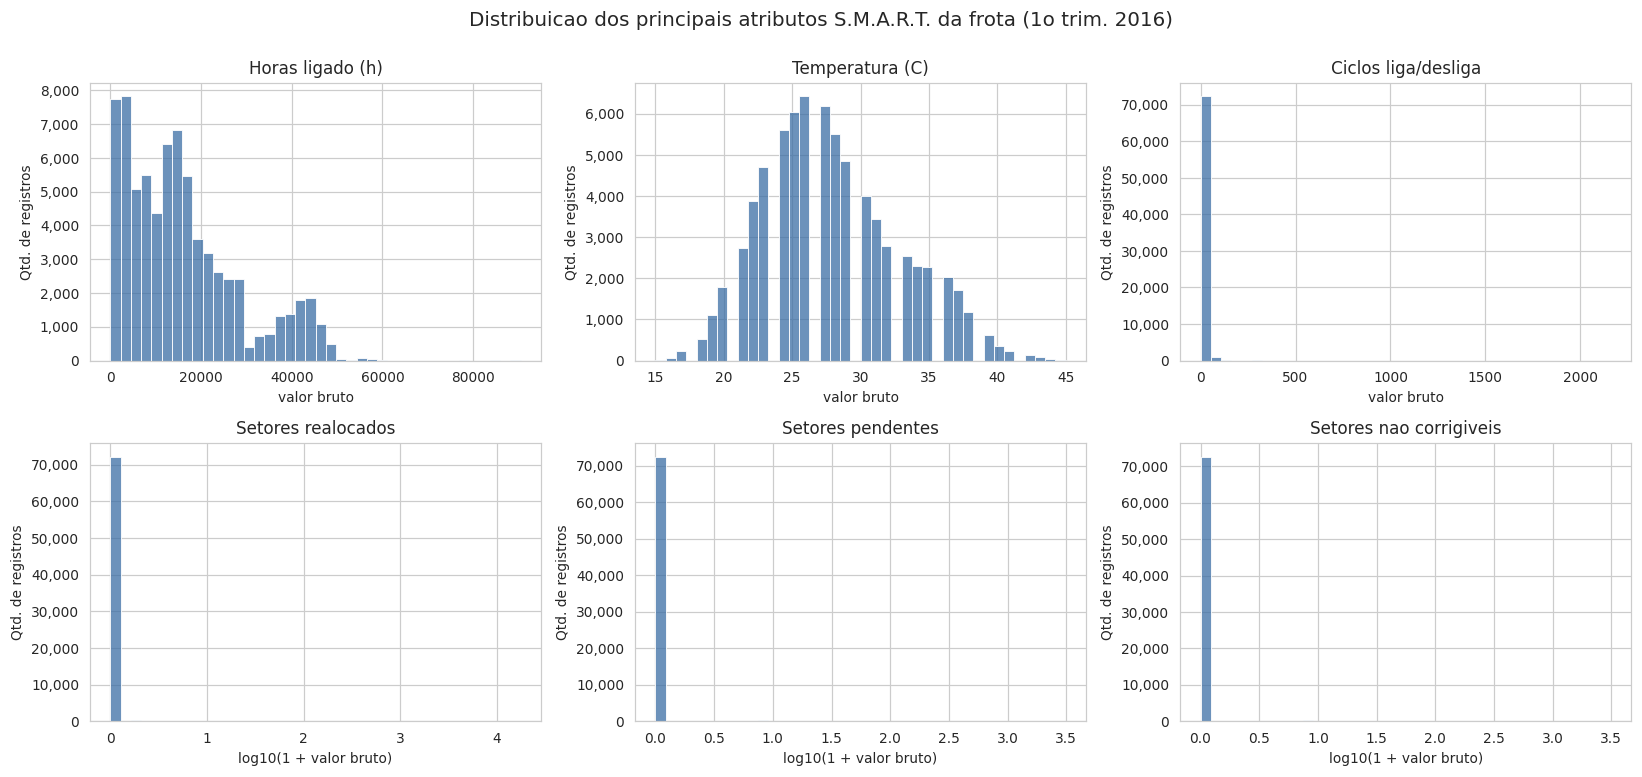

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
alvos = [('smart_9_raw',   'Horas ligado (h)',            False),
         ('smart_194_raw', 'Temperatura (C)',             False),
         ('smart_12_raw',  'Ciclos liga/desliga',         False),
         ('smart_5_raw',   'Setores realocados',          True),
         ('smart_197_raw', 'Setores pendentes',           True),
         ('smart_198_raw', 'Setores nao corrigiveis',     True)]

for ax, (col, titulo, log) in zip(axes.flat, alvos):
    serie = df_ml[col].dropna()
    if log:
        serie = np.log10(serie.clip(lower=0) + 1)
        ax.set_xlabel('log10(1 + valor bruto)')
    else:
        ax.set_xlabel('valor bruto')
    sns.histplot(serie, bins=40, ax=ax, color='#3b6ea5')
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('Qtd. de registros')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}'))

plt.suptitle('Distribuicao dos principais atributos S.M.A.R.T. da frota (1o trim. 2016)',
             y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

**Interpretação dos histogramas.** As três variáveis de cima são "contínuas e bem-comportadas": horas ligado mostra a composição etária da frota (coortes de compra aparecem como picos), a temperatura se concentra em uma faixa operacional estreita e controlada, e os ciclos liga/desliga são baixos — servidores de data center praticamente não desligam.

As três de baixo (em escala log, senão só se veria uma barra) são o oposto: **massivamente concentradas em zero**. Setores realocados, pendentes e não corrigíveis são exatamente os indicadores de dano físico, e o fato de a esmagadora maioria dos discos ter valor zero é o que torna esses atributos tão informativos — quando eles saem de zero, algo realmente aconteceu com aquele disco.

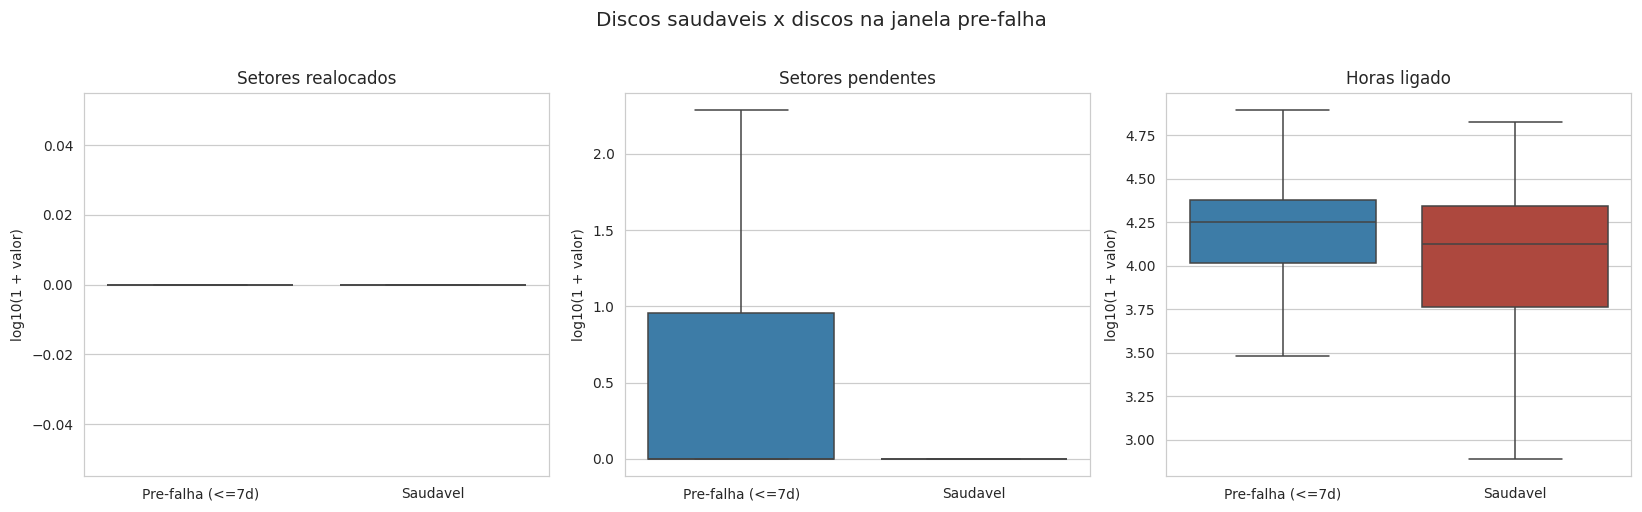

Percentual de discos COM pelo menos um setor problematico:
  Setores realocados      saudaveis  1.29%   pre-falha 14.12%   -> 11.0x mais frequente
  Setores pendentes       saudaveis  0.28%   pre-falha 30.82%   -> 109.4x mais frequente


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
comparacoes = [('smart_5_raw',   'Setores realocados'),
               ('smart_197_raw', 'Setores pendentes'),
               ('smart_9_raw',   'Horas ligado')]

for ax, (col, titulo) in zip(axes, comparacoes):
    tmp = df_ml[['alvo', col]].copy()
    tmp['grupo'] = np.where(tmp.alvo == 1, f'Pre-falha (<={JANELA_PRE_FALHA}d)', 'Saudavel')
    tmp[col] = np.log10(tmp[col].clip(lower=0) + 1)
    sns.boxplot(data=tmp, x='grupo', y=col, ax=ax, palette=['#2c7fb8', '#c0392b'],
                showfliers=False)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('log10(1 + valor)')
    ax.set_xlabel('')

plt.suptitle('Discos saudaveis x discos na janela pre-falha', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print('Percentual de discos COM pelo menos um setor problematico:')
for col, titulo in comparacoes[:2]:
    p0 = 100 * (df_ml.loc[df_ml.alvo == 0, col] > 0).mean()
    p1_ = 100 * (df_ml.loc[df_ml.alvo == 1, col] > 0).mean()
    print(f'  {titulo:22s}  saudaveis {p0:5.2f}%   pre-falha {p1_:5.2f}%'
          f'   -> {p1_/max(p0, 1e-9):.1f}x mais frequente')

**Este é o gráfico mais importante da EDA** — ele mostra que o sinal que queremos capturar realmente existe nos dados.

A diferença entre os dois grupos é gritante nos indicadores de setor. Entre os discos saudáveis, apenas **0,28%** têm algum setor pendente; entre os discos na janela pré-falha, **30,82%** têm — uma frequência **109 vezes maior**. Para setores realocados, a razão é de **11 vezes** (1,29% contra 14,12%).

Repare também no que o boxplot revela sobre a natureza do problema: mesmo entre os discos pré-falha, a *mediana* continua em zero. Ou seja, **cerca de 70% dos discos que vão falhar em até 7 dias não apresentam nenhum setor pendente** — eles morrem sem aviso (falha mecânica súbita do motor, do atuador ou da eletrônica). Isso estabelece um teto realista para qualquer modelo preditivo baseado em S.M.A.R.T. e explica, desde já, por que o *recall* do classificador na Seção 6.2 não chegará perto de 100%.

Em horas ligado a diferença é menor e mais sutil: os discos pré-falha tendem a ser um pouco mais velhos, mas há discos novos falhando e discos muito antigos saudáveis. Idade, sozinha, é um preditor fraco.

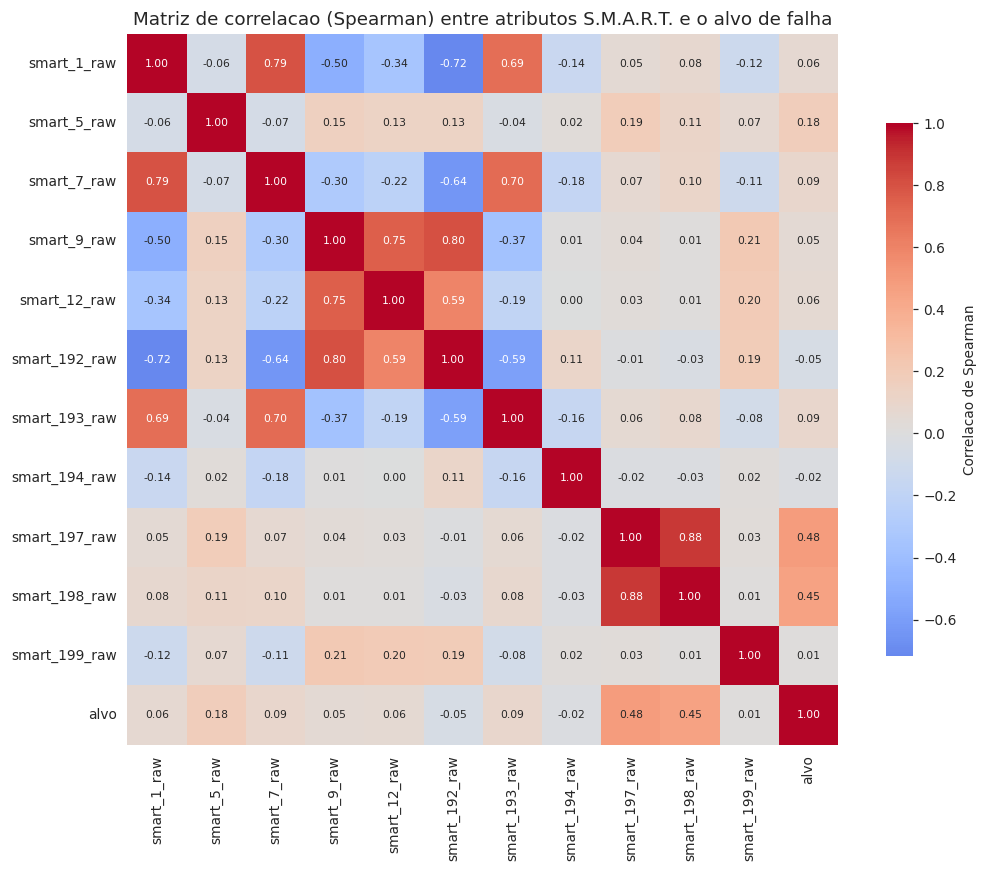

Correlacao de Spearman de cada atributo com o alvo (pre-falha):
smart_197_raw    0.485
smart_198_raw    0.455
smart_5_raw      0.178
smart_7_raw      0.091
smart_193_raw    0.088
smart_1_raw      0.064
smart_12_raw     0.061
smart_9_raw      0.054
smart_199_raw    0.015
smart_194_raw   -0.018
smart_192_raw   -0.046


In [11]:
plt.figure(figsize=(10, 8))
corr = df_ml[COLS_DESCR + ['alvo']].corr(method='spearman')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.75, 'label': 'Correlacao de Spearman'})
plt.title('Matriz de correlacao (Spearman) entre atributos S.M.A.R.T. e o alvo de falha',
          fontsize=12)
plt.tight_layout()
plt.show()

print('Correlacao de Spearman de cada atributo com o alvo (pre-falha):')
print(corr['alvo'].drop('alvo').sort_values(ascending=False).round(3).to_string())

**Leitura da matriz de correlação.** Usamos Spearman (correlação de postos) em vez de Pearson porque essas variáveis são fortemente assimétricas e cheias de zeros — Pearson seria dominado por alguns poucos valores extremos.

Olhando a última linha/coluna (a correlação com o alvo de pré-falha):

| Atributo | ρ com o alvo |
|---|---|
| Setores pendentes (`smart_197`) | **+0,485** |
| Setores não corrigíveis (`smart_198`) | **+0,455** |
| Setores realocados (`smart_5`) | +0,178 |
| Taxa de erro de busca (`smart_7`) | +0,091 |
| Horas ligado (`smart_9`) | +0,054 |
| **Temperatura (`smart_194`)** | **−0,018** |

Três conclusões:

1. **Setores pendentes e não corrigíveis são os sinais dominantes** — e note que eles são altamente correlacionados *entre si* (um setor pendente que não se recupera vira um não corrigível). São duas medidas do mesmo fenômeno físico.
2. **Setores realocados têm correlação bem menor do que se esperaria.** Faz sentido: realocar um setor é o disco *resolvendo* o problema com sucesso. Ter setores realocados é sinal de desgaste, mas ter setores *pendentes* é sinal de que o disco não está mais conseguindo resolver.
3. **A temperatura praticamente não se correlaciona com falha** (ρ ≈ −0,02). Isso reproduz um dos achados publicados mais conhecidos da própria Backblaze — dentro da faixa operacional de um data center bem refrigerado, temperatura não é o driver de falha que a intuição sugere.

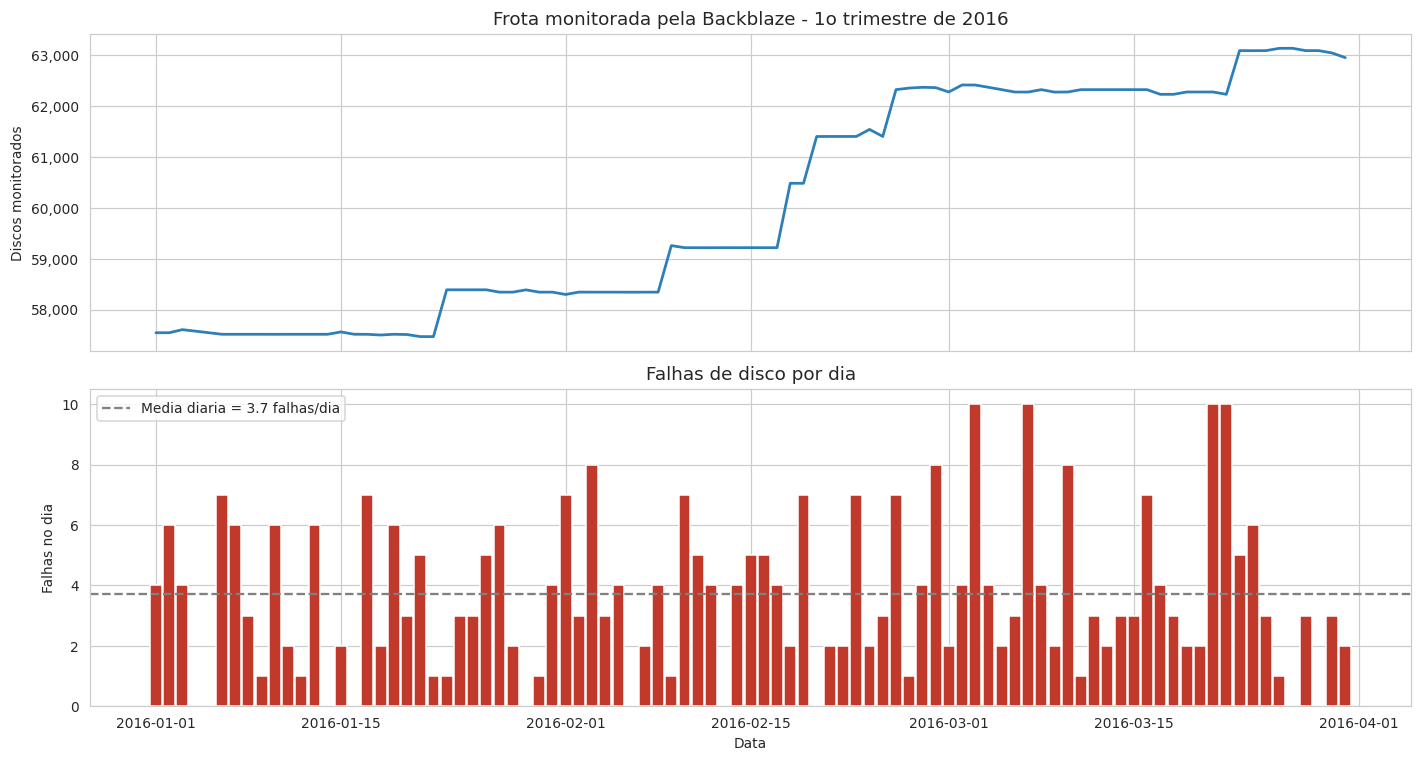

Frota no inicio do periodo .... 57,545 discos
Frota no fim do periodo ....... 62,952 discos (+9.4%)
Falhas por dia ................ media 3.7 | mediana 3 | min 0 | max 10
AFR agregado da frota ......... 2.25%


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(df_dias.date, df_dias.discos_ativos, color='#2c7fb8', lw=1.8)
axes[0].set_ylabel('Discos monitorados')
axes[0].set_title('Frota monitorada pela Backblaze - 1o trimestre de 2016', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v:,.0f}'))

axes[1].bar(df_dias.date, df_dias.falhas, color='#c0392b', width=0.9)
media = df_dias.falhas.mean()
axes[1].axhline(media, ls='--', color='gray',
                label=f'Media diaria = {media:.1f} falhas/dia')
axes[1].set_ylabel('Falhas no dia')
axes[1].set_xlabel('Data')
axes[1].set_title('Falhas de disco por dia', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Frota no inicio do periodo .... {df_dias.discos_ativos.iloc[0]:,} discos')
print(f'Frota no fim do periodo ....... {df_dias.discos_ativos.iloc[-1]:,} discos '
      f'({100*(df_dias.discos_ativos.iloc[-1]/df_dias.discos_ativos.iloc[0]-1):+.1f}%)')
print(f'Falhas por dia ................ media {df_dias.falhas.mean():.1f} | '
      f'mediana {df_dias.falhas.median():.0f} | min {df_dias.falhas.min()} | '
      f'max {df_dias.falhas.max()}')
print(f'AFR agregado da frota ......... '
      f'{df_dias.falhas.sum()/df_dias.discos_ativos.sum()*365*100:.2f}%')

**Leitura da série temporal.** A frota cresceu de **57.545 para 62.952 discos** ao longo do trimestre (**+9,4%**) — a Backblaze estava em expansão, e os degraus visíveis na curva superior são justamente a entrada de novos lotes em produção. Isso importa para a nossa análise: o denominador (disco-dias) não é constante, e é exatamente por isso que o AFR é calculado sobre disco-dias e não sobre o número de discos.

No painel inferior, o traço fundamental do problema: **uma média de 3,7 falhas por dia**, variando entre 0 e 10, sem tendência nem sazonalidade aparente no trimestre. Agregando tudo, a frota inteira operou com um **AFR de 2,25%**.

Para dimensionar a decisão: 2,25% ao ano em uma unidade de 5 PB com ~1.000 discos significa cerca de **22 substituições de disco por ano**. Cada uma dessas substituições é uma reconstrução de dados e uma janela em que a redundância está reduzida. É essa a consequência concreta que o eixo de Risco está medindo.

## 6. Avaliação de Risco

Esta é a seção que mais se beneficia de a base ser real. O risco é construído em três camadas complementares:

- **6.1 — AFR observado.** A taxa de falha que efetivamente ocorreu em campo, por modelo de disco, com intervalo de confiança.
- **6.2 — Classificador de falha.** Um Random Forest treinado sobre os atributos S.M.A.R.T. reais, que aprende *como* um disco se comporta antes de quebrar.
- **6.3 — Score de risco composto.** A consolidação das duas camadas em um único índice 0–100 por modelo, que alimentará a MCDA.

### 6.1 Taxa de Falha Anualizada (AFR) real por modelo

O AFR é a métrica padrão da indústria (e a que a própria Backblaze publica trimestralmente):

$$
AFR = \frac{\text{falhas observadas}}{\text{disco-dias observados}} \times 365 \times 100\%
$$

Um AFR de 2% significa: *se eu operar 100 discos desse modelo por um ano, espero perder cerca de 2*.

**Por que um intervalo de confiança é indispensável aqui.** Falha é um evento raro. Um modelo com 1 falha em 20.000 disco-dias produz um AFR pontual de 1,8% — mas essa única falha poderia facilmente ter sido 0 ou 3. Modelamos a contagem de falhas como um processo de **Poisson** e reportamos o intervalo exato de 95%, além de aplicar um **corte mínimo de disco-dias** para excluir modelos sem massa estatística. Sem isso, o ranking de risco seria dominado por ruído amostral.

In [13]:
DISCOS_MINIMOS = 450                              # frota minima para o AFR ser estavel
MIN_DISCO_DIAS = DISCOS_MINIMOS * len(dias_ok)    # equivalente em disco-dias no periodo
print(f'Corte adotado: {DISCOS_MINIMOS} discos operando o periodo inteiro '
      f'= {MIN_DISCO_DIAS:,} disco-dias\n')

def ic_poisson(k, exposicao, conf=0.95):
    '''IC exato de Poisson para a taxa, via relacao com a distribuicao qui-quadrado.'''
    a = 1 - conf
    lo = stats.chi2.ppf(a / 2, 2 * k) / 2 if k > 0 else 0.0
    hi = stats.chi2.ppf(1 - a / 2, 2 * (k + 1)) / 2
    return lo / exposicao, hi / exposicao

df_afr = df_modelos[df_modelos.disco_dias >= MIN_DISCO_DIAS].copy()
df_afr['discos_equiv'] = (df_afr.disco_dias / len(dias_ok)).round(0).astype(int)
df_afr['afr_%'] = df_afr.falhas / df_afr.disco_dias * 365 * 100

ics = [ic_poisson(k, dd) for k, dd in zip(df_afr.falhas, df_afr.disco_dias)]
df_afr['afr_ic_inf_%'] = [lo * 365 * 100 for lo, hi in ics]
df_afr['afr_ic_sup_%'] = [hi * 365 * 100 for lo, hi in ics]

df_afr = df_afr.sort_values('afr_%').reset_index(drop=True)

print(f'Modelos com >= {MIN_DISCO_DIAS:,} disco-dias: {len(df_afr)} '
      f'(de {len(df_modelos)} modelos presentes na base)')
print(f'Cobertura: {100*df_afr.disco_dias.sum()/df_modelos.disco_dias.sum():.1f}% '
      f'dos disco-dias e {100*df_afr.falhas.sum()/df_modelos.falhas.sum():.1f}% das falhas\n')

df_afr[['model', 'fabricante', 'capacidade_tb', 'discos_equiv', 'disco_dias',
        'falhas', 'afr_%', 'afr_ic_inf_%', 'afr_ic_sup_%']].style.format(
    {'disco_dias': '{:,.0f}', 'discos_equiv': '{:,.0f}',
     'afr_%': '{:.2f}', 'afr_ic_inf_%': '{:.2f}', 'afr_ic_sup_%': '{:.2f}'}
).background_gradient(subset=['afr_%'], cmap='RdYlGn_r').set_caption(
    'Taxa de falha anualizada (AFR) observada - 1o trimestre de 2016')

Corte adotado: 450 discos operando o periodo inteiro = 40,050 disco-dias

Modelos com >= 40,050 disco-dias: 11 (de 42 modelos presentes na base)
Cobertura: 97.9% dos disco-dias e 93.2% das falhas



,model,fabricante,capacidade_tb,discos_equiv,disco_dias,falhas,afr_%,afr_ic_inf_%,afr_ic_sup_%
0,HGST HMS5C4040BLE640,HGST,4.000000,"3,091","275,099",0,0.00,0.00,0.49
1,ST6000DX000,Seagate,6.000000,"1,882","167,498",0,0.00,0.00,0.80
2,HGST HMS5C4040ALE640,HGST,4.000000,"7,079","630,023",10,0.58,0.28,1.07
3,Hitachi HDS5C3030ALA630,Hitachi,3.000000,"4,557","405,555",8,0.72,0.31,1.42
4,Hitachi HDS723030ALA640,Hitachi,3.000000,999,"88,921",2,0.82,0.10,2.97
5,Hitachi HDS5C4040ALE630,Hitachi,4.000000,"2,635","234,547",7,1.09,0.44,2.24
6,ST500LM012 HN,Seagate,0.500000,565,"50,323",2,1.45,0.18,5.24
7,Hitachi HDS722020ALA330,Hitachi,2.000000,"4,434","394,626",17,1.57,0.92,2.52
8,ST4000DM000,Seagate,4.000000,"31,740","2,824,867",198,2.56,2.21,2.94
9,WDC WD30EFRX,Western Digital,3.000000,"1,049","93,342",10,3.91,1.88,7.19


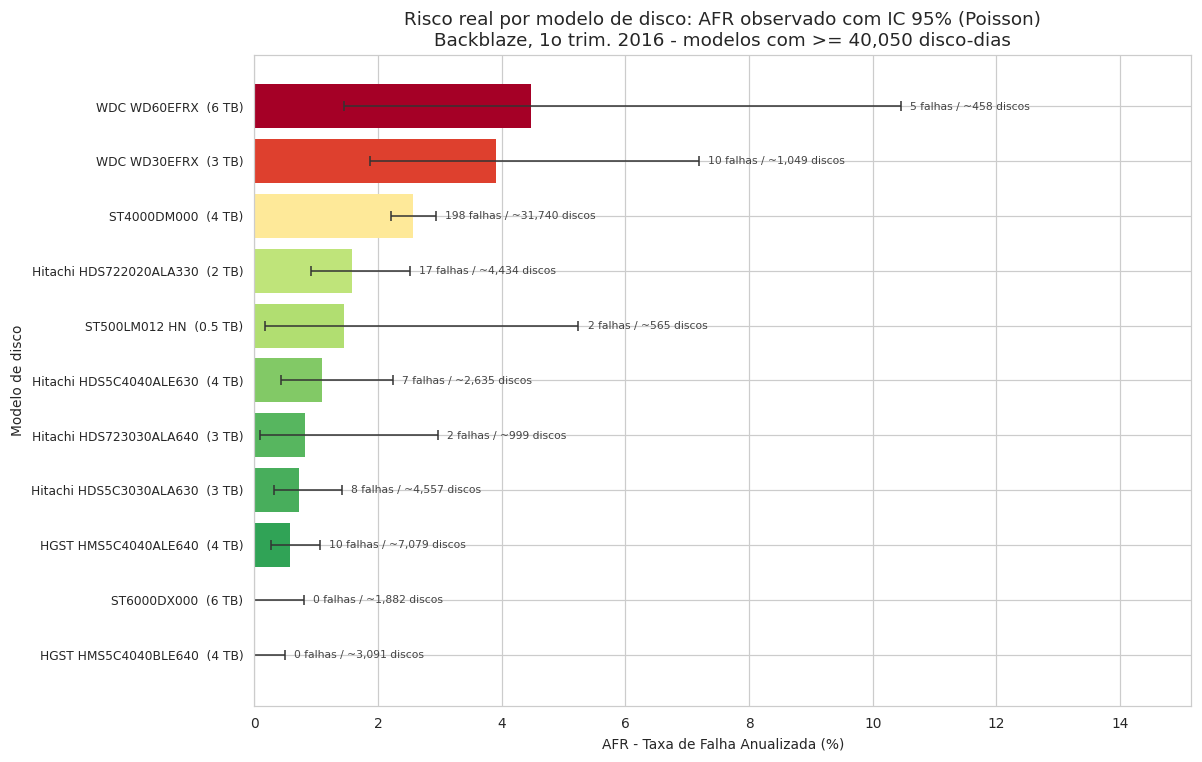

In [14]:
fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(df_afr))
erro = np.vstack([df_afr['afr_%'] - df_afr['afr_ic_inf_%'],
                  df_afr['afr_ic_sup_%'] - df_afr['afr_%']])
cores = plt.cm.RdYlGn_r(df_afr['afr_%'] / max(df_afr['afr_%'].max(), 1e-9))

ax.barh(y, df_afr['afr_%'], color=cores, edgecolor='none')
ax.errorbar(df_afr['afr_%'], y, xerr=erro, fmt='none', ecolor='#333', capsize=3, lw=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{m}  ({c:g} TB)" for m, c in zip(df_afr.model, df_afr.capacidade_tb)],
                   fontsize=8)
ax.set_xlabel('AFR - Taxa de Falha Anualizada (%)')
ax.set_ylabel('Modelo de disco')
ax.set_title('Risco real por modelo de disco: AFR observado com IC 95% (Poisson)\n'
             f'Backblaze, 1o trim. 2016 - modelos com >= {MIN_DISCO_DIAS:,} disco-dias', fontsize=12)

for i, (v, n, f) in enumerate(zip(df_afr['afr_%'], df_afr.discos_equiv, df_afr.falhas)):
    ax.text(df_afr['afr_ic_sup_%'].iloc[i] + 0.15, i, f'{f} falhas / ~{n:,} discos',
            va='center', fontsize=7, color='#444')

ax.set_xlim(0, df_afr['afr_ic_sup_%'].max() * 1.45)
plt.tight_layout()
plt.show()

**Leitura do AFR — o resultado central do eixo de Risco.**

Dos 42 modelos presentes na base, **11 têm massa estatística suficiente** (≥ 450 discos operando o trimestre inteiro). Eles representam **97,9% dos disco-dias** e **93,2% das falhas** — o corte descarta muitos modelos, mas quase nenhuma informação.

A dispersão entre os modelos é enorme e é isso que torna a decisão relevante:

- **Dois modelos não registraram nenhuma falha** no trimestre: o `HGST HMS5C4040BLE640` (0 falhas em 275.099 disco-dias) e o `ST6000DX000` (0 falhas em 167.498 disco-dias).
- No extremo oposto, o `WDC WD60EFRX` apresentou **AFR de 4,48%** e o `ST4000DM000`, **2,56%**.

**Por que as barras de erro são indispensáveis aqui.** Um AFR pontual de 0,00% não significa "este disco nunca falha" — significa "não observamos falhas nesta janela". O que o intervalo de confiança entrega é o limite superior honesto: para o `HGST HMS5C4040BLE640` podemos afirmar com 95% de confiança que o AFR real é **no máximo 0,49%**, enquanto para o `ST6000DX000` o teto é **0,80%**. Os dois têm AFR pontual idêntico, mas o HGST tem **mais evidência** por trás — 65% mais disco-dias observados. Esse é o tipo de distinção que um ranking sem incerteza esconderia.

O efeito oposto aparece no `WDC WD60EFRX`: AFR pontual de 4,48%, mas intervalo indo de **1,45% a 10,45%**. Foram apenas 5 falhas. A barra é longa porque o dado é fraco — e a decisão precisa saber disso.

Já o `ST4000DM000` é o caso oposto em termos de confiança: 198 falhas em 2,8 milhões de disco-dias produzem um intervalo estreitíssimo (2,21% a 2,94%). Esse número é sólido. E é o modelo mais numeroso da frota — cerca de 31.700 discos, mais da metade do parque.

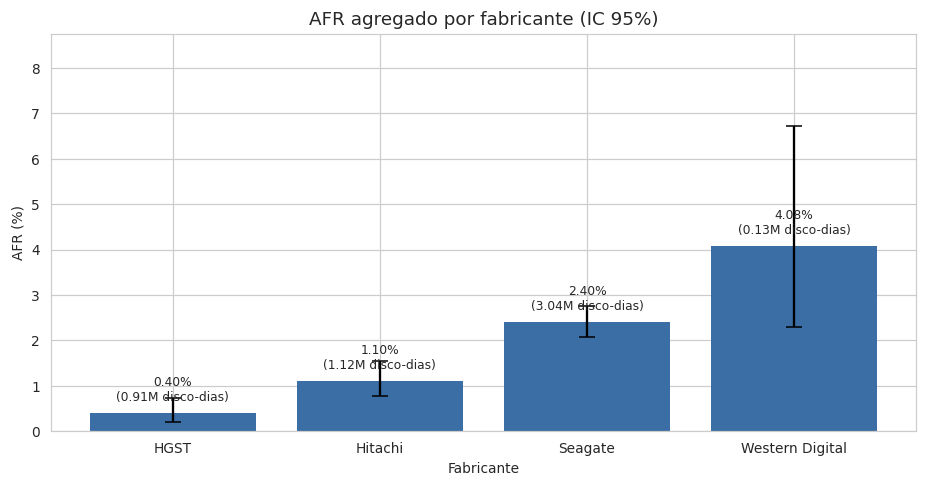

,modelos,disco_dias,falhas,afr_%,afr_ic_inf_%,afr_ic_sup_%
fabricante,,,,,,
HGST,2,905122,10,0.403,0.193,0.742
Hitachi,4,1123649,34,1.104,0.765,1.543
Seagate,3,3042688,200,2.399,2.078,2.756
Western Digital,2,134104,15,4.083,2.285,6.734


In [15]:
fab = (df_afr.groupby('fabricante')
       .agg(modelos=('model', 'nunique'), disco_dias=('disco_dias', 'sum'),
            falhas=('falhas', 'sum')))
fab['afr_%'] = fab.falhas / fab.disco_dias * 365 * 100
ics = [ic_poisson(k, dd) for k, dd in zip(fab.falhas, fab.disco_dias)]
fab['afr_ic_inf_%'] = [lo * 365 * 100 for lo, hi in ics]
fab['afr_ic_sup_%'] = [hi * 365 * 100 for lo, hi in ics]
fab = fab.sort_values('afr_%')

fig, ax = plt.subplots(figsize=(8.5, 4.5))
erro = np.vstack([fab['afr_%'] - fab['afr_ic_inf_%'], fab['afr_ic_sup_%'] - fab['afr_%']])
ax.bar(fab.index, fab['afr_%'], color='#3b6ea5', yerr=erro, capsize=5, edgecolor='none')
ax.set_ylabel('AFR (%)')
ax.set_xlabel('Fabricante')
ax.set_title('AFR agregado por fabricante (IC 95%)', fontsize=12)
for i, (v, dd) in enumerate(zip(fab['afr_%'], fab.disco_dias)):
    ax.text(i, v + (fab['afr_ic_sup_%'].max() * 0.04), f'{v:.2f}%\n({dd/1e6:.2f}M disco-dias)',
            ha='center', fontsize=8)
ax.set_ylim(0, fab['afr_ic_sup_%'].max() * 1.3)
plt.tight_layout()
plt.show()
fab.round(3)

**Leitura por fabricante.** Agregando os modelos, aparece uma ordenação clara e estatisticamente separada:

| Fabricante | AFR | IC 95% | Disco-dias |
|---|---|---|---|
| HGST | **0,40%** | 0,19% – 0,74% | 905 mil |
| Hitachi | **1,10%** | 0,77% – 1,54% | 1,12 M |
| Seagate | **2,40%** | 2,08% – 2,76% | 3,04 M |
| Western Digital | **4,08%** | 2,29% – 6,73% | 134 mil |

Os intervalos de HGST, Hitachi e Seagate **não se sobrepõem** — a diferença entre eles é real, não ruído amostral. A HGST apresentou uma taxa de falha cerca de **6 vezes menor** que a Seagate no período.

Duas ressalvas importantes, porém, antes de concluir "compre HGST":

1. **O caso da Western Digital é frágil.** Seu intervalo vai de 2,3% a 6,7% — baseado em apenas 15 falhas e 3,4% dos disco-dias da frota. Ela aparece como a pior, mas com pouquíssima evidência.
2. **Há um viés de composição.** A Backblaze usava majoritariamente discos Seagate de linha *consumer* de 4 TB (o `ST4000DM000` sozinho é 53% de todos os disco-dias), enquanto os HGST eram modelos de linha diferente. Parte da diferença é de fabricante, parte é de segmento de produto. É por isso que a MCDA decide por **modelo**, e não por fabricante.

### 6.2 Classificador de Falha a partir dos Atributos S.M.A.R.T.

O AFR diz *quanto* um modelo falha, mas não diz *como reconhecer* um disco prestes a falhar. Para isso treinamos um **Random Forest Classifier** sobre os atributos S.M.A.R.T. reais.

**Definição do alvo.** `alvo = 1` se o registro pertence à **janela de até 7 dias antes** da falha daquele disco; `alvo = 0` para discos saudáveis amostrados. Usar apenas o dia exato da falha daria pouquíssimos exemplos positivos e, na prática, nenhuma utilidade operacional — o que interessa a um data center é ter **dias de antecedência** para migrar os dados.

**Cuidados metodológicos (importantes para o resultado não ser uma ilusão):**

1. **Separação por disco, não por linha.** Um mesmo disco aparece em vários dias. Se o treino e o teste dividissem linhas aleatoriamente, o modelo veria o *mesmo disco* nos dois lados e o desempenho seria inflado. Usamos `GroupShuffleSplit` agrupando por `serial_number` — nenhum disco aparece simultaneamente no treino e no teste.
2. **Desbalanceamento severo.** Os positivos são uma fração mínima da amostra. Por isso usamos `class_weight='balanced'` e avaliamos por **ROC-AUC** e **precisão média (PR-AUC)**, não por acurácia — um modelo que chutasse "nunca falha" teria acurácia altíssima e utilidade zero.

In [16]:
FEATURES = SMART_COLS
X = df_ml[FEATURES].fillna(0).values
y = df_ml['alvo'].values
grupos = df_ml['serial_number'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
idx_tr, idx_te = next(gss.split(X, y, groups=grupos))
X_tr, X_te, y_tr, y_te = X[idx_tr], X[idx_te], y[idx_tr], y[idx_te]

print(f'Treino: {len(y_tr):,} registros ({y_tr.sum():,} positivos)')
print(f'Teste : {len(y_te):,} registros ({y_te.sum():,} positivos)')
print(f'Discos distintos em comum entre treino e teste: '
      f'{len(set(grupos[idx_tr]) & set(grupos[idx_te]))}  <- deve ser 0')

clf = RandomForestClassifier(n_estimators=400, max_depth=14, min_samples_leaf=4,
                             class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)
clf.fit(X_tr, y_tr)

proba_te = clf.predict_proba(X_te)[:, 1]
auc  = roc_auc_score(y_te, proba_te)
ap   = average_precision_score(y_te, proba_te)
base_rand = y_te.mean()

print(f'\nROC-AUC ................ {auc:.4f}')
print(f'PR-AUC (precisao media)  {ap:.4f}   (linha de base aleatoria = {base_rand:.4f}'
      f'  ->  ganho de {ap/base_rand:.1f}x)')
print('\nRelatorio de classificacao (limiar 0,5):')
print(classification_report(y_te, (proba_te >= 0.5).astype(int),
                            target_names=['Saudavel', 'Pre-falha'], digits=3))

Treino: 51,261 registros (1,705 positivos)
Teste : 22,179 registros (725 positivos)
Discos distintos em comum entre treino e teste: 0  <- deve ser 0



ROC-AUC ................ 0.8047
PR-AUC (precisao media)  0.4411   (linha de base aleatoria = 0.0327  ->  ganho de 13.5x)

Relatorio de classificacao (limiar 0,5):
              precision    recall  f1-score   support

    Saudavel      0.982     0.987     0.984     21454
   Pre-falha      0.543     0.454     0.494       725

    accuracy                          0.970     22179
   macro avg      0.762     0.720     0.739     22179
weighted avg      0.967     0.970     0.968     22179



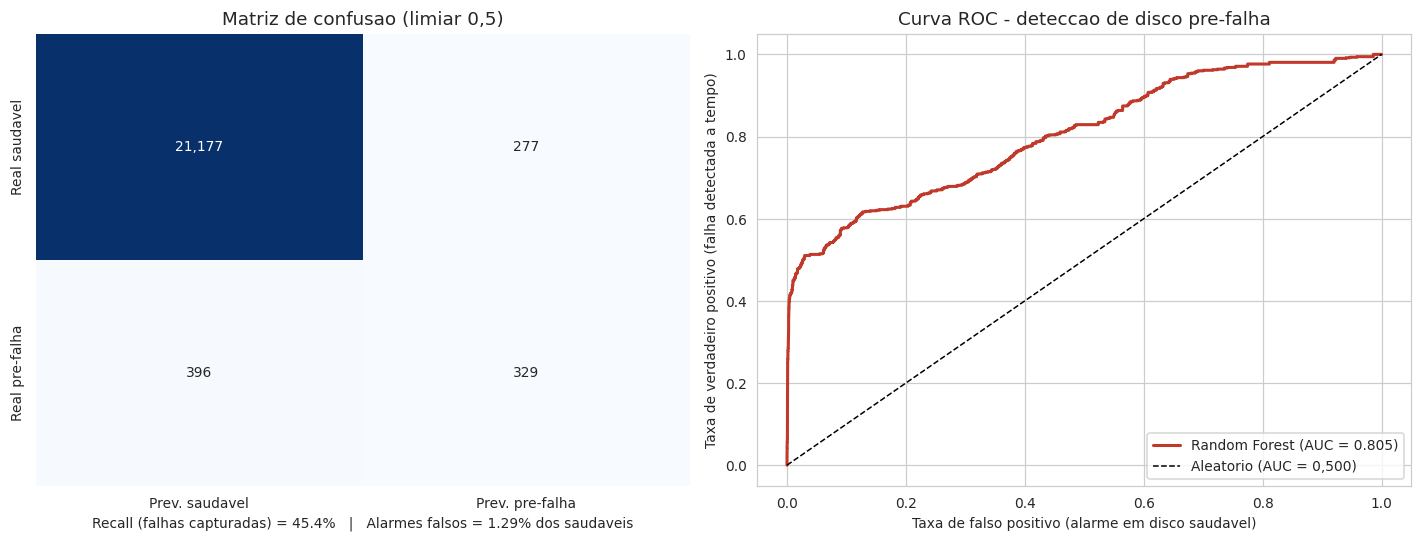

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- matriz de confusao
cm = confusion_matrix(y_te, (proba_te >= 0.5).astype(int))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Prev. saudavel', 'Prev. pre-falha'],
            yticklabels=['Real saudavel', 'Real pre-falha'])
axes[0].set_title('Matriz de confusao (limiar 0,5)', fontsize=12)
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f'Recall (falhas capturadas) = {tp/(tp+fn):.1%}   |   '
                   f'Alarmes falsos = {fp/(fp+tn):.2%} dos saudaveis')

# --- curva ROC
fpr, tpr, _ = roc_curve(y_te, proba_te)
axes[1].plot(fpr, tpr, color='#c0392b', lw=2, label=f'Random Forest (AUC = {auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio (AUC = 0,500)')
axes[1].set_xlabel('Taxa de falso positivo (alarme em disco saudavel)')
axes[1].set_ylabel('Taxa de verdadeiro positivo (falha detectada a tempo)')
axes[1].set_title('Curva ROC - deteccao de disco pre-falha', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

**Leitura do desempenho do classificador.**

**ROC-AUC = 0,805** significa que, sorteando ao acaso um disco pré-falha e um disco saudável, o modelo atribui maior probabilidade ao pré-falha em **80,5% das vezes**. É um desempenho sólido para prever um evento raro a partir apenas da telemetria do próprio disco.

**PR-AUC = 0,441 contra uma linha de base aleatória de 0,033** — um **ganho de 13,5×**. Esta é a métrica mais honesta em problemas assim desbalanceados: ela mede a capacidade de encontrar as agulhas no palheiro, não de acertar o palheiro.

**Na matriz de confusão** (limiar 0,5), o modelo captura **45,4% dos discos pré-falha** com uma **precisão de 54,3%** — quando ele dispara o alarme, tem razão em pouco mais da metade das vezes.

**O que isso significa na prática, e por que 45% já é útil.** Detectar antecipadamente quase metade das falhas permite migrar os dados e substituir o disco em janela programada, em vez de reagir a uma falha em produção. E lembre-se do que a EDA já tinha mostrado: cerca de 70% dos discos que falham não emitem nenhum sinal de setor pendente — uma parte relevante das falhas é mecanicamente súbita e **nenhum modelo baseado em S.M.A.R.T. conseguiria antecipá-las**. O teto do problema é baixo; o modelo está operando razoavelmente perto dele.

**Conclusão para a decisão:** predição de falha é um complemento, **não um substituto da redundância**. É exatamente por isso que o eixo de Risco da MCDA dá peso maior ao AFR observado (60%) do que à saída do classificador (25%) — e é por isso que a arquitetura de 5 PB continua assumindo codificação Reed-Solomon 17+3.

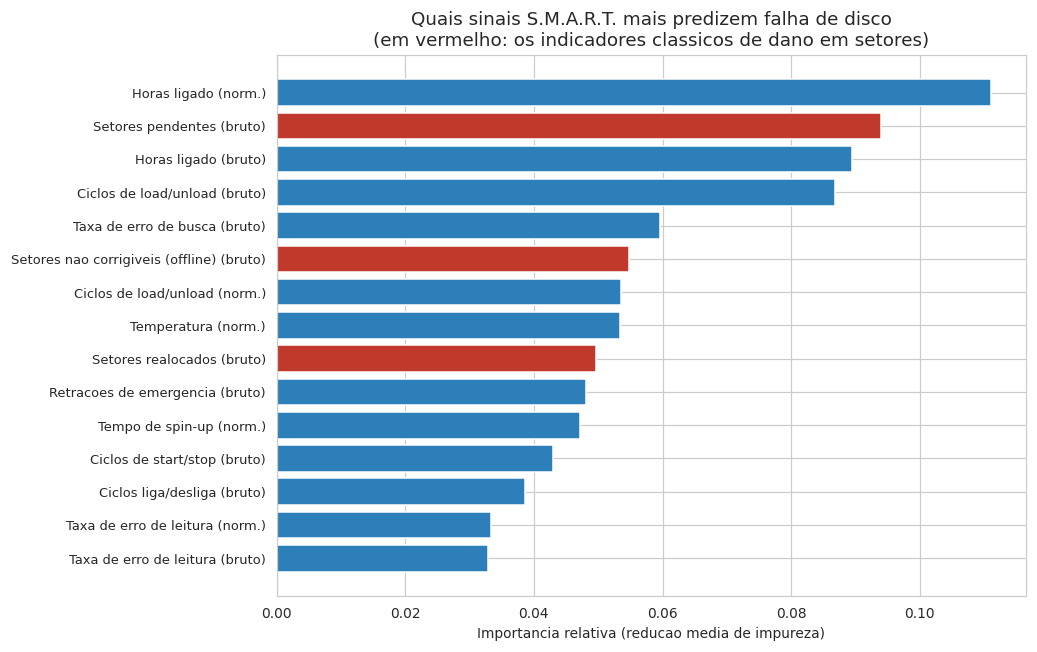

Top 10 atributos por importancia:
   11.1%   Horas ligado (norm.)
    9.4%   Setores pendentes (bruto)
    8.9%   Horas ligado (bruto)
    8.7%   Ciclos de load/unload (bruto)
    6.0%   Taxa de erro de busca (bruto)
    5.5%   Setores nao corrigiveis (offline) (bruto)
    5.4%   Ciclos de load/unload (norm.)
    5.3%   Temperatura (norm.)
    5.0%   Setores realocados (bruto)
    4.8%   Retracoes de emergencia (bruto)

Soma da importancia dos indicadores de setor (5, 197, 198): 21.1%


In [18]:
imp = pd.Series(clf.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)

NOMES = {
    'smart_5':   'Setores realocados',
    'smart_197': 'Setores pendentes',
    'smart_198': 'Setores nao corrigiveis (offline)',
    'smart_187': 'Erros nao corrigiveis reportados',
    'smart_9':   'Horas ligado',
    'smart_1':   'Taxa de erro de leitura',
    'smart_7':   'Taxa de erro de busca',
    'smart_3':   'Tempo de spin-up',
    'smart_4':   'Ciclos de start/stop',
    'smart_10':  'Retentativas de spin',
    'smart_12':  'Ciclos liga/desliga',
    'smart_192': 'Retracoes de emergencia',
    'smart_193': 'Ciclos de load/unload',
    'smart_194': 'Temperatura',
    'smart_199': 'Erros CRC UltraDMA',
}
def rotular(c):
    base = '_'.join(c.split('_')[:2])
    tipo = 'norm.' if c.endswith('normalized') else 'bruto'
    return f'{NOMES.get(base, base)} ({tipo})'

fig, ax = plt.subplots(figsize=(9.5, 6))
cores = ['#c0392b' if any(k in c for k in ['smart_5_', 'smart_197_', 'smart_198_'])
         else '#2c7fb8' for c in imp.index]
ax.barh(range(len(imp)), imp.values[::-1], color=cores[::-1])
ax.set_yticks(range(len(imp)))
ax.set_yticklabels([rotular(c) for c in imp.index[::-1]], fontsize=8.5)
ax.set_xlabel('Importancia relativa (reducao media de impureza)')
ax.set_title('Quais sinais S.M.A.R.T. mais predizem falha de disco\n'
             '(em vermelho: os indicadores classicos de dano em setores)', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 10 atributos por importancia:')
for c, v in imp.head(10).items():
    print(f'  {100*v:5.1f}%   {rotular(c)}')
print(f'\nSoma da importancia dos indicadores de setor (5, 197, 198): '
      f'{100*sum(v for c, v in zip(FEATURES, clf.feature_importances_) if any(k in c for k in ["smart_5_", "smart_197_", "smart_198_"])):.1f}%')

**Leitura das importâncias.** Os atributos mais usados pelo Random Forest são:

| Importância | Atributo |
|---|---|
| 11,1% | Horas ligado (normalizado) |
| 9,4% | **Setores pendentes** (bruto) |
| 8,9% | Horas ligado (bruto) |
| 8,7% | Ciclos de load/unload (bruto) |
| 6,0% | Taxa de erro de busca (bruto) |
| 5,5% | **Setores não corrigíveis** (bruto) |
| 5,0% | **Setores realocados** (bruto) |

Os três indicadores clássicos de dano em setores (destacados em vermelho no gráfico) somam **21,1%** da importância total — concentrados em poucas variáveis, contra as 28 disponíveis.

**Um detalhe metodológico que vale notar.** As horas ligado aparecem no topo, mas a correlação direta delas com o alvo era de apenas +0,054. Isso não é contradição: importância em Random Forest não é correlação. O modelo usa `smart_9` principalmente como **variável de contexto** — ela permite às árvores interpretar os demais sinais condicionados à idade do disco (um setor pendente em um disco de 6 meses significa algo bem diferente de um em um disco de 5 anos). Variáveis contínuas com muitos valores distintos também tendem a atrair mais divisões, o que infla um pouco sua importância por impureza.

Já `smart_197` (setores pendentes) faz o trabalho *direto*: é a variável com maior correlação individual com o alvo e a segunda em importância. Isso confirma nos dados aquilo que a literatura de confiabilidade de discos vem apontando há anos — **setor pendente é o alarme que realmente antecede a falha**.

### 6.3 Score de Risco Composto por Modelo

As duas camadas anteriores são consolidadas em um **score de risco 0–100** (maior = pior), por modelo de disco, que será um dos três eixos da MCDA:

| Componente | O que mede | Origem | Peso |
|---|---|---|---|
| `risco_afr` | Taxa de falha anualizada observada em campo | **Dado real** | **60%** |
| `risco_ml` | Probabilidade média de pré-falha atribuída pelo Random Forest aos discos vivos daquele modelo | **Dado real + modelo** | **25%** |
| `risco_idade` | Horas de operação acumuladas da frota instalada daquele modelo | **Dado real** | **15%** |

O AFR carrega o maior peso por ser a evidência mais direta e menos mediada. O componente de ML é complementar e valioso porque enxerga **degradação ainda não convertida em falha** — um modelo pode ainda não ter falhado muito e já estar acumulando setores ruins. O componente de idade penaliza modelos cuja frota já está avançada no ciclo de vida (risco futuro, não passado).

Todos os componentes são normalizados por min-max dentro do conjunto de modelos analisados e os pesos são **parâmetros gerenciais explícitos** — a Seção 9.1 testa exatamente o quanto a recomendação depende deles.

In [19]:
# probabilidade media de pre-falha atribuida pelo RF aos discos SAUDAVEIS de cada modelo
saud = df_ml[df_ml.alvo == 0].copy()
saud['prob_prefalha'] = clf.predict_proba(saud[FEATURES].fillna(0).values)[:, 1]
perfil = saud.groupby('model').agg(prob_ml=('prob_prefalha', 'mean'),
                                   horas_medias=('smart_9_raw', 'mean'),
                                   n_amostras=('prob_prefalha', 'size'))

df_risco = df_afr.merge(perfil, left_on='model', right_index=True, how='left')
df_risco[['prob_ml', 'horas_medias']] = df_risco[['prob_ml', 'horas_medias']].fillna(
    df_risco[['prob_ml', 'horas_medias']].median())

def minmax(s):
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else pd.Series(0.0, index=s.index)

PESOS_RISCO = {'afr': 0.60, 'ml': 0.25, 'idade': 0.15}
df_risco['risco_afr']   = minmax(df_risco['afr_%'])
df_risco['risco_ml']    = minmax(df_risco['prob_ml'])
df_risco['risco_idade'] = minmax(df_risco['horas_medias'])
df_risco['score_risco'] = 100 * (PESOS_RISCO['afr']   * df_risco.risco_afr +
                                 PESOS_RISCO['ml']    * df_risco.risco_ml +
                                 PESOS_RISCO['idade'] * df_risco.risco_idade)
df_risco = df_risco.sort_values('score_risco').reset_index(drop=True)

df_risco[['model', 'fabricante', 'capacidade_tb', 'afr_%', 'prob_ml',
          'horas_medias', 'score_risco']].style.format(
    {'afr_%': '{:.2f}', 'prob_ml': '{:.3f}', 'horas_medias': '{:,.0f}',
     'score_risco': '{:.1f}'}
).background_gradient(subset=['score_risco'], cmap='RdYlGn_r').set_caption(
    'Score de risco composto por modelo (0 = melhor, 100 = pior)')

,model,fabricante,capacidade_tb,afr_%,prob_ml,horas_medias,score_risco
0,HGST HMS5C4040BLE640,HGST,4.000000,0.00,0.019,"15,694",3.5
1,ST6000DX000,Seagate,6.000000,0.00,0.068,"7,951",8.1
2,HGST HMS5C4040ALE640,HGST,4.000000,0.58,0.026,"13,534",11.5
3,Hitachi HDS5C3030ALA630,Hitachi,3.000000,0.72,0.025,"32,814",21.2
4,ST500LM012 HN,Seagate,0.500000,1.45,0.048,"6,996",24.1
5,Hitachi HDS723030ALA640,Hitachi,3.000000,0.82,0.030,"36,684",24.9
6,Hitachi HDS5C4040ALE630,Hitachi,4.000000,1.09,0.041,"25,150",25.5
7,Hitachi HDS722020ALA330,Hitachi,2.000000,1.57,0.021,"43,749",36.5
8,ST4000DM000,Seagate,4.000000,2.56,0.170,"9,032",58.9
9,WDC WD30EFRX,Western Digital,3.000000,3.91,0.096,"15,096",67.9


**Leitura do score de risco composto.** A tabela ordena os 11 modelos do mais seguro ao mais arriscado, e a consolidação das três camadas produz algumas reordenações interessantes em relação ao AFR puro:

- **`HGST HMS5C4040BLE640` (score 3,5)** é o mais seguro em todas as dimensões simultaneamente: AFR 0,00% com a maior massa de evidência do estudo, e a menor probabilidade média de pré-falha atribuída pelo Random Forest (0,019).
- **`ST6000DX000` (score 8,1)** também tem AFR 0,00%, mas **o classificador enxerga nele quase 4 vezes mais sinal de degradação** (0,068 contra 0,019). Ou seja: ainda não falhou, mas já apresenta telemetria menos limpa. Este é precisamente o valor de ter a camada de ML — ela vê o que o contador de falhas ainda não registrou.
- **`Hitachi HDS722020ALA330` (score 36,5)** tem AFR moderado (1,57%) e probabilidade de ML baixa (0,021), mas é penalizado pela idade: sua frota acumula **43.749 horas médias** de operação — cerca de 5 anos ligada. É um modelo no fim do ciclo de vida.
- **`WDC WD60EFRX` (score 86,3)** é o pior em todas as três camadas ao mesmo tempo: pior AFR (4,48%), segunda maior probabilidade de ML (0,178) e idade intermediária.

O contraste entre `ST4000DM000` (AFR 2,56%, prob. ML 0,170) e `Hitachi HDS722020ALA330` (AFR 1,57%, prob. ML 0,021) resume bem o que o score composto acrescenta: o Seagate falha mais **e** está acumulando sinal de degradação; o Hitachi falha menos do que sua idade sugeriria e está com telemetria limpa.

## 7. Análise de Custo

A base da Backblaze **não contém preços**. Portanto, diferentemente do eixo de Risco, o eixo de Custo é um **modelo heurístico explícito de mercado** — mas *alimentado pelos números reais de falha medidos na Seção 6*, que é justamente o que o torna útil: o custo de reposição de cada modelo é calculado a partir do AFR que aquele modelo efetivamente apresentou.

### Premissas assumidas (todas parametrizadas e auditáveis)

| Parâmetro | Valor assumido | Justificativa |
|---|---|---|
| Capacidade útil alvo da nova unidade | **5 PB (5.000 TB)** | Porte típico de uma unidade inicial |
| Codificação de redundância | **Reed-Solomon 17+3** | Esquema real usado nos *Vaults* da Backblaze → sobrecarga de 20/17 ≈ **17,6%** |
| Preço de um disco | **US$ 45 fixos + (capacidade × US$/TB)** | Um HDD tem um custo de mecânica que não escala com a capacidade; por isso discos pequenos têm pior US$/TB efetivo |
| US$/TB — Seagate / WD / Toshiba / HGST / Hitachi | **18 / 20 / 19 / 22 / 22** | Faixa de mercado para HDD de capacidade na época; HGST/Hitachi historicamente com prêmio de preço |
| Chassi de armazenamento | **60 discos por chassi, US$ 4.000/chassi** | Referência do *Storage Pod* da Backblaze |
| Horizonte de operação | **5 anos** | Vida útil contábil típica |
| Mão de obra de troca de disco | **+15%** sobre o preço do disco reposto | Custo de campo por evento de substituição |
| Consumo por disco | **7,5 W** médios, **PUE 1,4**, **US$ 0,10/kWh** | Faixa usual para HDD 3,5" em data center |

### Formulação

$$
N_{discos} = \left\lceil \frac{C_{alvo} \times 1{,}176}{cap_{modelo}} \right\rceil
\qquad
N_{chassis} = \left\lceil \frac{N_{discos}}{60} \right\rceil
$$

$$
p_{disco} = 45 + cap \cdot p_{TB}
\qquad
\underbrace{CapEx = N_{discos} \cdot p_{disco} + N_{chassis} \cdot 4000}_{\text{aquisição}}
\qquad
\underbrace{OpEx_{rep} = N_{discos} \cdot \frac{AFR}{100} \cdot 5 \cdot p_{disco} \cdot 1{,}15}_{\text{reposição, dirigida pelo AFR real}}
$$

$$
OpEx_{energia} = N_{discos} \cdot 7{,}5\,W \cdot 1{,}4 \cdot 24 \cdot 365 \cdot 5 \cdot \frac{0{,}10}{1000}
\qquad
Custo_{total} = CapEx + OpEx_{rep} + OpEx_{energia}
$$

> **Escopo do custo.** O modelo cobre a camada que depende da escolha do disco: discos, chassis, reposição e energia. Ele **não** inclui prédio, rede, racks, refrigeração ou pessoal — esses custos existem, mas são praticamente iguais para qualquer modelo de disco e por isso não mudariam o ranking.

O ponto central: **um modelo barato por TB mas com AFR alto pode sair mais caro no horizonte de 5 anos** — e é exatamente essa compensação que o gráfico a seguir torna visível.

In [20]:
# ---------------------------------------------------------------------------
# PARAMETROS DE CUSTO (premissas de mercado - NAO vem da base)
# ---------------------------------------------------------------------------
CAPACIDADE_ALVO_TB = 5_000        # 5 PB uteis
FATOR_REDUNDANCIA  = 20 / 17      # Reed-Solomon 17+3
DISCOS_POR_CHASSI  = 60
CUSTO_CHASSI_USD   = 4_000
HORIZONTE_ANOS     = 5
FATOR_MAO_DE_OBRA  = 1.15
POTENCIA_DISCO_W   = 7.5
PUE                = 1.4
PRECO_KWH_USD      = 0.10

# preco de um disco = componente fixo (mecanica, motor, PCB) + componente por TB (midia)
PRECO_BASE_DISCO_USD = 45.0
USD_POR_TB = {'Seagate': 18.0, 'Western Digital': 20.0, 'Toshiba': 19.0,
              'HGST': 22.0, 'Hitachi': 22.0, 'Samsung': 20.0, 'Outro': 20.0}

def modelar_custo(linha, usd_por_tb=USD_POR_TB, alvo_tb=CAPACIDADE_ALVO_TB):
    cap = linha.capacidade_tb
    p_tb = usd_por_tb[linha.fabricante]
    n_discos  = math.ceil(alvo_tb * FATOR_REDUNDANCIA / cap)
    n_chassis = math.ceil(n_discos / DISCOS_POR_CHASSI)
    preco_disco = PRECO_BASE_DISCO_USD + cap * p_tb

    capex_discos = n_discos * preco_disco
    capex_chassi = n_chassis * CUSTO_CHASSI_USD
    opex_repos   = (n_discos * (linha['afr_%'] / 100) * HORIZONTE_ANOS
                    * preco_disco * FATOR_MAO_DE_OBRA)
    opex_energia = (n_discos * POTENCIA_DISCO_W * PUE * 24 * 365
                    * HORIZONTE_ANOS * PRECO_KWH_USD / 1000)
    return pd.Series({'n_discos': n_discos, 'n_chassis': n_chassis,
                      'preco_disco_usd': preco_disco,
                      'capex_discos_usd': capex_discos, 'capex_chassi_usd': capex_chassi,
                      'opex_reposicao_usd': opex_repos, 'opex_energia_usd': opex_energia,
                      'custo_total_usd': capex_discos + capex_chassi + opex_repos + opex_energia})

df_custo = pd.concat([df_risco, df_risco.apply(modelar_custo, axis=1)], axis=1)
df_custo['custo_por_tb_util'] = df_custo.custo_total_usd / CAPACIDADE_ALVO_TB
df_custo['discos_repostos_5a'] = (df_custo.n_discos * df_custo['afr_%'] / 100 * HORIZONTE_ANOS).round(0)
df_custo = df_custo.sort_values('custo_total_usd').reset_index(drop=True)

df_custo[['model', 'fabricante', 'capacidade_tb', 'n_discos', 'n_chassis', 'afr_%',
          'discos_repostos_5a', 'capex_discos_usd', 'opex_reposicao_usd',
          'opex_energia_usd', 'custo_total_usd', 'custo_por_tb_util']].style.format(
    {'n_discos': '{:,.0f}', 'n_chassis': '{:,.0f}', 'afr_%': '{:.2f}',
     'discos_repostos_5a': '{:,.0f}', 'capex_discos_usd': 'US$ {:,.0f}',
     'opex_reposicao_usd': 'US$ {:,.0f}', 'opex_energia_usd': 'US$ {:,.0f}',
     'custo_total_usd': 'US$ {:,.0f}', 'custo_por_tb_util': 'US$ {:,.2f}'}
).background_gradient(subset=['custo_total_usd'], cmap='RdYlGn_r').set_caption(
    f'Custo total de 5 anos para {CAPACIDADE_ALVO_TB:,} TB uteis, por modelo de disco')

,model,fabricante,capacidade_tb,n_discos,n_chassis,afr_%,discos_repostos_5a,capex_discos_usd,opex_reposicao_usd,opex_energia_usd,custo_total_usd,custo_por_tb_util
0,ST6000DX000,Seagate,6.000000,981,17,0.00,0,"US$ 150,093",US$ 0,"US$ 45,116","US$ 263,209",US$ 52.64
1,WDC WD60EFRX,Western Digital,6.000000,981,17,4.48,220,"US$ 161,865","US$ 41,670","US$ 45,116","US$ 316,652",US$ 63.33
2,HGST HMS5C4040BLE640,HGST,4.000000,"1,471",25,0.00,0,"US$ 195,643",US$ 0,"US$ 67,651","US$ 363,294",US$ 72.66
3,ST4000DM000,Seagate,4.000000,"1,471",25,2.56,188,"US$ 172,107","US$ 25,318","US$ 67,651","US$ 365,076",US$ 73.02
4,HGST HMS5C4040ALE640,HGST,4.000000,"1,471",25,0.58,43,"US$ 195,643","US$ 6,517","US$ 67,651","US$ 369,812",US$ 73.96
5,Hitachi HDS5C4040ALE630,Hitachi,4.000000,"1,471",25,1.09,80,"US$ 195,643","US$ 12,254","US$ 67,651","US$ 375,549",US$ 75.11
6,Hitachi HDS5C3030ALA630,Hitachi,3.000000,"1,961",33,0.72,71,"US$ 217,671","US$ 9,012","US$ 90,186","US$ 448,869",US$ 89.77
7,Hitachi HDS723030ALA640,Hitachi,3.000000,"1,961",33,0.82,80,"US$ 217,671","US$ 10,275","US$ 90,186","US$ 450,133",US$ 90.03
8,WDC WD30EFRX,Western Digital,3.000000,"1,961",33,3.91,383,"US$ 205,905","US$ 46,297","US$ 90,186","US$ 474,388",US$ 94.88
9,Hitachi HDS722020ALA330,Hitachi,2.000000,"2,942",50,1.57,231,"US$ 261,838","US$ 23,673","US$ 135,303","US$ 620,814",US$ 124.16


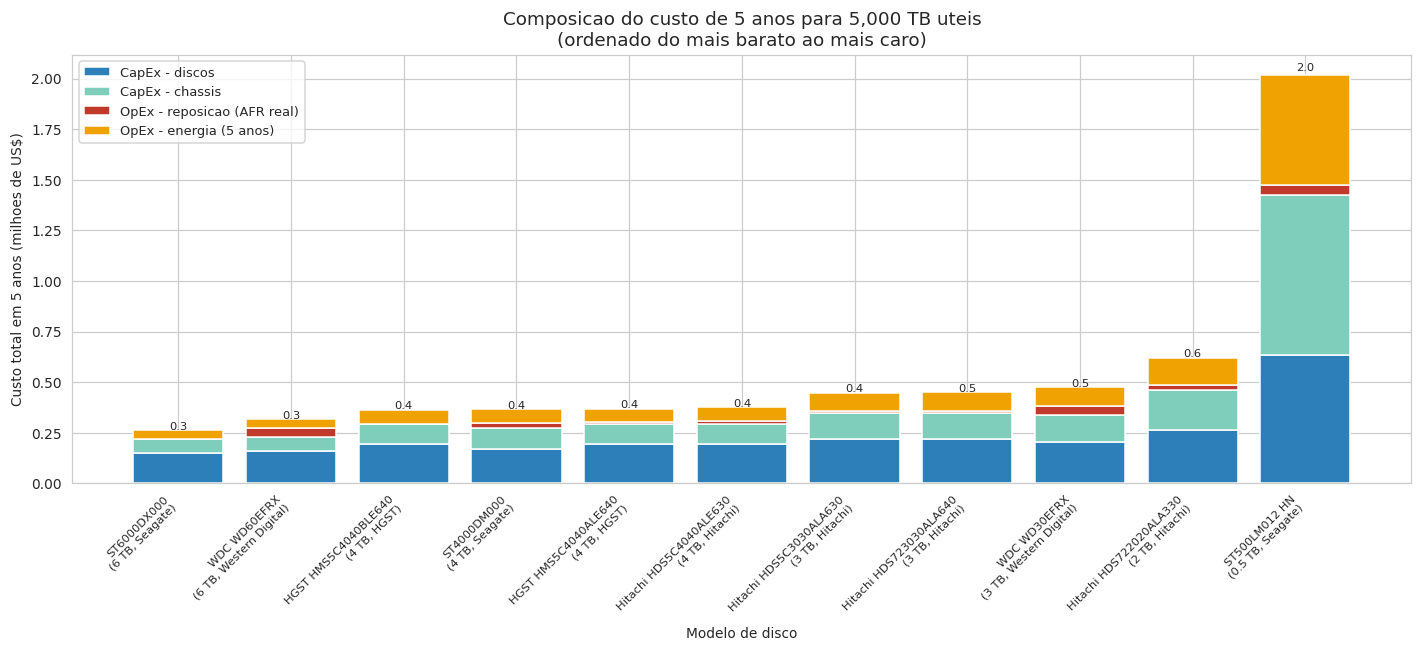

In [21]:
d = df_custo.head(14).copy()
rot = [f'{m}\n({c:g} TB, {f})' for m, c, f in zip(d.model, d.capacidade_tb, d.fabricante)]
x = np.arange(len(d))

fig, ax = plt.subplots(figsize=(13, 6))
componentes = [('capex_discos_usd',   'CapEx - discos',       '#2c7fb8'),
               ('capex_chassi_usd',   'CapEx - chassis',      '#7fcdbb'),
               ('opex_reposicao_usd', 'OpEx - reposicao (AFR real)', '#c0392b'),
               ('opex_energia_usd',   'OpEx - energia (5 anos)',     '#f0a202')]
base = np.zeros(len(d))
for col, rotulo, cor in componentes:
    ax.bar(x, d[col] / 1e6, bottom=base / 1e6, label=rotulo, color=cor)
    base = base + d[col].values

ax.set_xticks(x); ax.set_xticklabels(rot, rotation=45, ha='right', fontsize=7.5)
ax.set_ylabel('Custo total em 5 anos (milhoes de US$)')
ax.set_xlabel('Modelo de disco')
ax.set_title(f'Composicao do custo de 5 anos para {CAPACIDADE_ALVO_TB:,} TB uteis\n'
             '(ordenado do mais barato ao mais caro)', fontsize=12)
ax.legend(loc='upper left', fontsize=8.5)
for i, v in enumerate(base / 1e6):
    ax.text(i, v * 1.01, f'{v:.1f}', ha='center', fontsize=7.5)
plt.tight_layout()
plt.show()

**Leitura do custo — e o efeito que só aparece quando risco vira dinheiro.**

O gráfico mostra dois mecanismos econômicos distintos operando ao mesmo tempo:

**1. Capacidade unitária domina o custo total.** Atingir 5 PB com discos de 6 TB exige 981 discos em 17 chassis; com discos de 4 TB, 1.471 discos em 25 chassis; com os de 0,5 TB do `ST500LM012 HN`, **11.765 discos em 197 chassis**. Por isso esse último modelo custa **US$ 2,02 milhões (US$ 403/TB)** contra **US$ 263 mil (US$ 52,64/TB)** do vencedor — quase **8 vezes mais caro** pela mesma capacidade útil. O custo de chassi e de energia escala com o *número de discos*, não com os terabytes.

**2. O AFR real vira uma linha de custo concreta.** Compare os dois modelos de 6 TB, que precisam exatamente do mesmo número de discos e chassis:

| | `ST6000DX000` | `WDC WD60EFRX` |
|---|---|---|
| AFR observado | 0,00% | 4,48% |
| Discos repostos em 5 anos | **0** | **~220** |
| OpEx de reposição | US$ 0 | **US$ 41.670** |
| Custo total | US$ 263.209 | US$ 316.652 |

A diferença de **US$ 53 mil (+20%)** entre eles vem quase inteiramente da confiabilidade — não do preço de compra. É exatamente o efeito que o enunciado do trabalho pedia: **o risco medido em dados reais se traduz em custo**.

O mesmo aparece no `ST4000DM000`: apesar de o disco Seagate ser mais barato por TB que o HGST equivalente (CapEx de US$ 172 mil contra US$ 196 mil), seus **US$ 25 mil de reposição** praticamente anulam a vantagem — os dois terminam empatados em torno de US$ 364 mil. **O disco mais barato não foi o mais barato.**

## 8. Estimativa de Tempo de Implantação

Como o custo, o tempo **não existe na base** e é modelado como heurística explícita — mas também ancorada no risco real medido.

### Premissas assumidas

| Parâmetro | Valor | Justificativa |
|---|---|---|
| *Lead time* de aquisição | Seagate 4 sem. · WD 5 · Toshiba 6 · HGST 6 · Hitachi 8 | Volume de produção e disponibilidade no canal; Hitachi já era linha em descontinuação em 2016 |
| Instalação e cabeamento | **0,05 semana por chassi** | ~2 chassis/dia por equipe, com 2 equipes em paralelo |
| *Burn-in* base | **2 semanas** | Teste de estresse padrão antes de entrar em produção |
| Ampliação do *burn-in* pelo risco | **até +150%** | Modelos com risco maior exigem janela de queima mais longa para eliminar mortalidade infantil antes de receber dados de cliente |

$$
T_{total} = \underbrace{T_{aquisicao}^{fabricante}}_{\text{compra}}
\; + \; \underbrace{0{,}05 \cdot N_{chassis}}_{\text{instalação}}
\; + \; \underbrace{2 \cdot \left(1 + 1{,}5 \cdot risco_{norm}\right)}_{\text{burn-in ajustado pelo risco real}}
$$

Este é o eixo em que a **capacidade do disco** tem efeito mais direto: atingir 5 PB com discos de 8 TB exige metade dos chassis que com discos de 4 TB, e portanto muito menos tempo de instalação física.

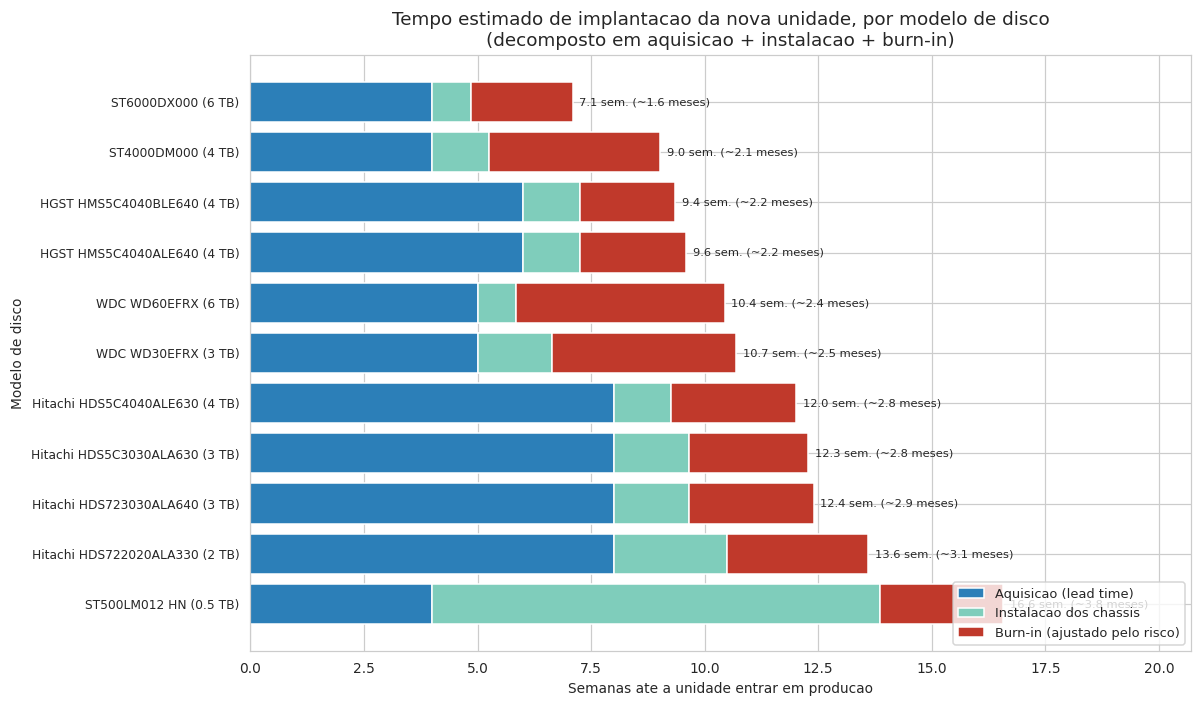

In [22]:
LEAD_TIME_SEMANAS = {'Seagate': 4, 'Western Digital': 5, 'Toshiba': 6,
                     'HGST': 6, 'Hitachi': 8, 'Samsung': 6, 'Outro': 6}
SEMANAS_POR_CHASSI = 0.05
BURN_IN_BASE       = 2.0
BURN_IN_FATOR_RISCO = 1.5

df_tempo = df_custo.copy()
df_tempo['risco_norm_0_1'] = df_tempo.score_risco / 100
df_tempo['t_aquisicao']  = df_tempo.fabricante.map(LEAD_TIME_SEMANAS)
df_tempo['t_instalacao'] = SEMANAS_POR_CHASSI * df_tempo.n_chassis
df_tempo['t_burn_in']    = BURN_IN_BASE * (1 + BURN_IN_FATOR_RISCO * df_tempo.risco_norm_0_1)
df_tempo['tempo_total_semanas'] = (df_tempo.t_aquisicao + df_tempo.t_instalacao
                                   + df_tempo.t_burn_in)
df_tempo['tempo_total_meses']   = df_tempo.tempo_total_semanas / 4.345
df_tempo = df_tempo.sort_values('tempo_total_semanas').reset_index(drop=True)

d = df_tempo.copy()
rot = [f'{m} ({c:g} TB)' for m, c in zip(d.model, d.capacidade_tb)]
y = np.arange(len(d))

fig, ax = plt.subplots(figsize=(11, 6.5))
esq = np.zeros(len(d))
for col, rotulo, cor in [('t_aquisicao', 'Aquisicao (lead time)', '#2c7fb8'),
                         ('t_instalacao', 'Instalacao dos chassis', '#7fcdbb'),
                         ('t_burn_in', 'Burn-in (ajustado pelo risco)', '#c0392b')]:
    ax.barh(y, d[col], left=esq, label=rotulo, color=cor)
    esq = esq + d[col].values

ax.set_yticks(y); ax.set_yticklabels(rot, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Semanas ate a unidade entrar em producao')
ax.set_ylabel('Modelo de disco')
ax.set_title('Tempo estimado de implantacao da nova unidade, por modelo de disco\n'
             '(decomposto em aquisicao + instalacao + burn-in)', fontsize=12)
ax.legend(loc='lower right', fontsize=8.5)
for i, v in enumerate(esq):
    ax.text(v + 0.15, i, f'{v:.1f} sem. (~{v/4.345:.1f} meses)', va='center', fontsize=7.5)
ax.set_xlim(0, esq.max() * 1.25)
plt.tight_layout()
plt.show()

**Leitura do tempo de implantação.** A faixa vai de **7,1 semanas** (`ST6000DX000`) a **16,6 semanas** (`ST500LM012 HN`) — uma diferença de mais de dois meses no *time-to-market* da unidade.

A decomposição mostra de onde vem cada diferença:

- **Aquisição** é o componente dominante e depende só do fabricante: 4 semanas para Seagate contra 6 para HGST e 8 para Hitachi. É por isso que os modelos Hitachi aparecem na metade de baixo apesar de terem risco moderado — a premissa de 8 semanas de *lead time* (linha em descontinuação em 2016) os penaliza pesadamente.
- **Instalação** é onde a capacidade unitária reaparece: 0,9 semana para os 17 chassis do modelo de 6 TB contra **9,9 semanas** para os 197 chassis do modelo de 0,5 TB.
- **Burn-in** varia pouco em termos absolutos (de 2,1 a 4,6 semanas), mas é o único componente que responde diretamente ao risco medido. Os modelos mais arriscados exigem uma janela de queima proporcionalmente maior antes de receber dados de cliente.

Vale notar o `ST4000DM000`: ele termina em **9,0 semanas**, um dos prazos mais curtos, mesmo tendo o segundo pior score de risco. O *lead time* curto da Seagate compensa o burn-in estendido. É um bom lembrete de que **as três dimensões não são redundantes entre si** — um modelo pode ser rápido e arriscado ao mesmo tempo, e é justamente por isso que a decisão precisa de uma matriz multicritério em vez de um único indicador.

## 9. Matriz de Decisão Multicritério (MCDA)

Agora as três dimensões são combinadas. Cada eixo é normalizado por min-max para [0, 1] **no sentido "quanto maior, pior"**, e o score final inverte a escala para que **maior = melhor**:

$$
Score = 100 \times \Big(1 - \big(w_{risco}\cdot risco_{norm} + w_{custo}\cdot custo_{norm} + w_{tempo}\cdot tempo_{norm}\big)\Big)
$$

**Pesos adotados como caso-base:**

| Critério | Peso | Justificativa |
|---|---|---|
| Risco | **0,45** | É a única dimensão medida em dados reais e a que carrega consequência irreversível: falha de disco significa reconstrução de dados e janela de vulnerabilidade para o cliente |
| Custo | **0,35** | Determina a viabilidade econômica da unidade no horizonte de 5 anos |
| Tempo | **0,20** | Importante para o *time-to-market*, mas uma unidade entregue tarde ainda é recuperável — dados perdidos, não |

Esses pesos são uma **decisão gerencial, não estatística**. Por isso as seções 9.1 e 9.2 verificam se a recomendação sobrevive quando eles (e os próprios dados) variam.

In [23]:
PESOS_MCDA = {'risco': 0.45, 'custo': 0.35, 'tempo': 0.20}

mcda = df_tempo.copy()
mcda['risco_norm'] = minmax(mcda.score_risco)
mcda['custo_norm'] = minmax(mcda.custo_total_usd)
mcda['tempo_norm'] = minmax(mcda.tempo_total_semanas)
mcda['score_decisao'] = 100 * (1 - (PESOS_MCDA['risco'] * mcda.risco_norm +
                                    PESOS_MCDA['custo'] * mcda.custo_norm +
                                    PESOS_MCDA['tempo'] * mcda.tempo_norm))
mcda = mcda.sort_values('score_decisao', ascending=False).reset_index(drop=True)
mcda['posicao'] = mcda.index + 1

mcda[['posicao', 'model', 'fabricante', 'capacidade_tb', 'afr_%', 'score_risco',
      'custo_total_usd', 'tempo_total_semanas', 'score_decisao']].style.format(
    {'afr_%': '{:.2f}', 'score_risco': '{:.1f}', 'custo_total_usd': 'US$ {:,.0f}',
     'tempo_total_semanas': '{:.1f}', 'score_decisao': '{:.1f}'}
).background_gradient(subset=['score_decisao'], cmap='RdYlGn').hide(axis='index').set_caption(
    'Ranking MCDA completo - Risco x Custo x Tempo (score 0-100, maior e melhor)')

posicao,model,fabricante,capacidade_tb,afr_%,score_risco,custo_total_usd,tempo_total_semanas,score_decisao
1,ST6000DX000,Seagate,6.000000,0.00,8.1,"US$ 263,209",7.1,97.5
2,HGST HMS5C4040BLE640,HGST,4.000000,0.00,3.5,"US$ 363,294",9.4,93.2
3,HGST HMS5C4040ALE640,HGST,4.000000,0.58,11.5,"US$ 369,812",9.6,88.3
4,Hitachi HDS5C3030ALA630,Hitachi,3.000000,0.72,21.2,"US$ 448,869",12.3,75.8
5,Hitachi HDS5C4040ALE630,Hitachi,4.000000,1.09,25.5,"US$ 375,549",12.0,75.4
6,Hitachi HDS723030ALA640,Hitachi,3.000000,0.82,24.9,"US$ 450,133",12.4,73.5
7,ST4000DM000,Seagate,4.000000,2.56,58.9,"US$ 365,076",9.0,63.8
8,Hitachi HDS722020ALA330,Hitachi,2.000000,1.57,36.5,"US$ 620,814",13.6,61.2
9,WDC WD30EFRX,Western Digital,3.000000,3.91,67.9,"US$ 474,388",10.7,53.2
10,WDC WD60EFRX,Western Digital,6.000000,4.48,86.3,"US$ 316,652",10.4,46.9


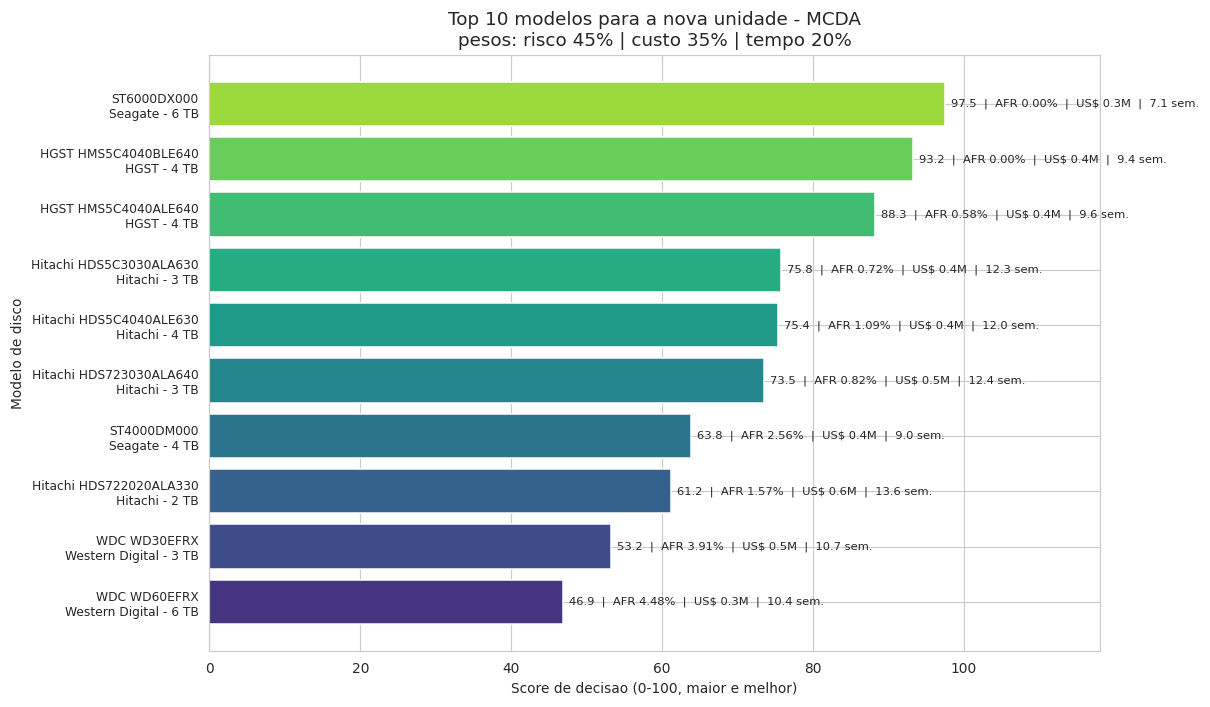

In [24]:
top10 = mcda.head(10).copy()
rot = [f'{m}\n{f} - {c:g} TB' for m, f, c in
       zip(top10.model, top10.fabricante, top10.capacidade_tb)]

fig, ax = plt.subplots(figsize=(11, 6.5))
cores = plt.cm.viridis(np.linspace(0.15, 0.85, len(top10)))[::-1]
ax.barh(range(len(top10)), top10.score_decisao, color=cores)
ax.set_yticks(range(len(top10))); ax.set_yticklabels(rot, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Score de decisao (0-100, maior e melhor)')
ax.set_ylabel('Modelo de disco')
ax.set_title('Top 10 modelos para a nova unidade - MCDA\n'
             f"pesos: risco {PESOS_MCDA['risco']:.0%} | custo {PESOS_MCDA['custo']:.0%} "
             f"| tempo {PESOS_MCDA['tempo']:.0%}", fontsize=12)
for i, (s, a, ct, t) in enumerate(zip(top10.score_decisao, top10['afr_%'],
                                      top10.custo_total_usd, top10.tempo_total_semanas)):
    ax.text(s + 0.8, i, f'{s:.1f}  |  AFR {a:.2f}%  |  US$ {ct/1e6:.1f}M  |  {t:.1f} sem.',
            va='center', fontsize=7.5)
ax.set_xlim(0, 118)
plt.tight_layout()
plt.show()

**Leitura do ranking MCDA.**

O **`ST6000DX000` (Seagate, 6 TB)** lidera com score **97,5**, e a razão é que ele é o único modelo a ficar simultaneamente no topo das três dimensões: AFR observado de 0,00%, o menor custo total (US$ 263 mil) e o menor prazo (7,1 semanas).

Em segundo, o **`HGST HMS5C4040BLE640`** com **93,2**. E aqui está a tensão mais interessante da análise: **este modelo é mais seguro que o vencedor** (score de risco 3,5 contra 8,1, e com evidência estatística mais forte — 275 mil disco-dias sem falha contra 167 mil). Ele perde porque seus 4 TB exigem 50% mais discos e chassis, o que custa **US$ 100 mil a mais** e **2,3 semanas a mais** de implantação.

Ou seja: **a diferença entre o 1º e o 2º lugar não é de confiabilidade — é de densidade**. Esta é a informação acionável que o gráfico entrega ao decisor, e é uma decisão que muda se a organização tiver apetite de risco diferente do caso-base. A Seção 9.1 quantifica exatamente isso.

No fundo do ranking, o **`ST500LM012 HN` (score 33,8)** é eliminado não por risco (AFR 1,45%, intermediário) mas por economia: 11.765 discos para 5 PB é um projeto economicamente inviável. E o **`WDC WD60EFRX` (46,9)** é o oposto — tem a mesma densidade do vencedor e custo próximo, mas é destruído pelo AFR de 4,48%.

### 9.1 Análise de Sensibilidade dos Pesos

O ranking acima depende de três números escolhidos por julgamento gerencial (0,45 / 0,35 / 0,20). A pergunta que um sistema de apoio à decisão precisa responder é: **a recomendação muda se esses pesos mudarem?**

Sorteamos **1.000 combinações de pesos** de uma distribuição de **Dirichlet** centrada no caso-base (mas com dispersão real em torno dele), recalculamos o ranking em cada sorteio e medimos, para cada modelo, a frequência com que ele aparece no Top 5 e em 1º lugar. Um modelo que só vence com um conjunto muito específico de pesos é uma recomendação frágil.

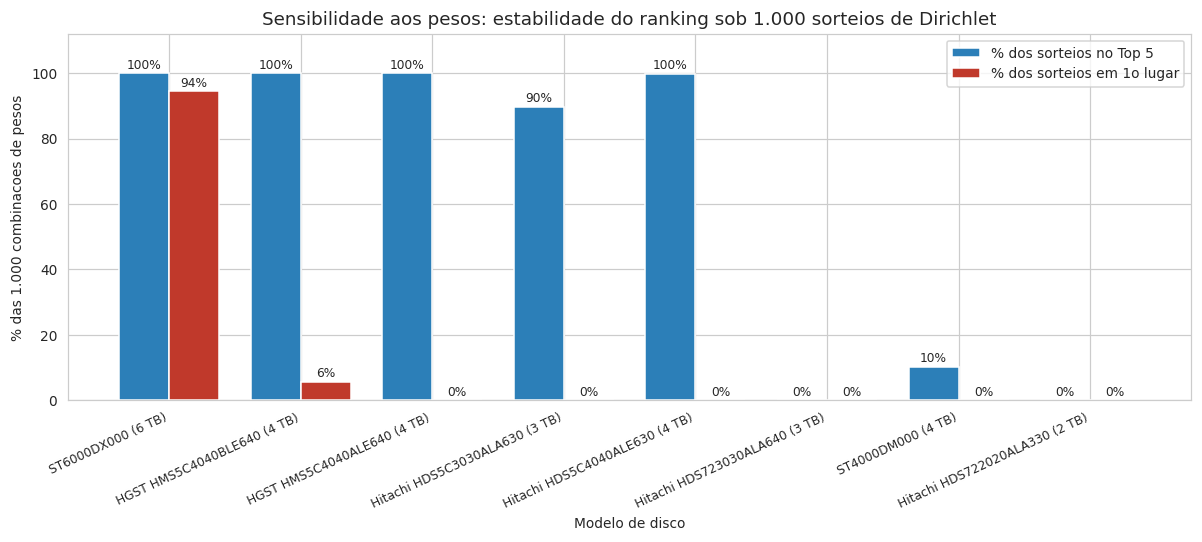

 posicao                   model  score_decisao  estab_top5_pesos_%  estab_1o_pesos_%
       1             ST6000DX000      97.509234               100.0              94.4
       2    HGST HMS5C4040BLE640      93.228557               100.0               5.6
       3    HGST HMS5C4040ALE640      88.277311               100.0               0.0
       4 Hitachi HDS5C3030ALA630      75.758894                89.7               0.0
       5 Hitachi HDS5C4040ALE630      75.414426                99.7               0.0
       6 Hitachi HDS723030ALA640      73.456386                 0.0               0.0
       7             ST4000DM000      63.831886                10.3               0.0
       8 Hitachi HDS722020ALA330      61.241580                 0.0               0.0


In [25]:
np.random.seed(RANDOM_STATE)
N_SORTEIOS = 1_000
ALPHA = np.array([PESOS_MCDA['risco'], PESOS_MCDA['custo'], PESOS_MCDA['tempo']]) * 12

cont_top5 = np.zeros(len(mcda)); cont_1o = np.zeros(len(mcda))
M = mcda[['risco_norm', 'custo_norm', 'tempo_norm']].values

for _ in range(N_SORTEIOS):
    w = np.random.dirichlet(ALPHA)
    s = 100 * (1 - M @ w)
    ordem = np.argsort(-s)
    cont_top5[ordem[:5]] += 1
    cont_1o[ordem[0]] += 1

mcda['estab_top5_pesos_%'] = 100 * cont_top5 / N_SORTEIOS
mcda['estab_1o_pesos_%']   = 100 * cont_1o / N_SORTEIOS

d = mcda.head(8)
rot = [f'{m} ({c:g} TB)' for m, c in zip(d.model, d.capacidade_tb)]
x = np.arange(len(d)); larg = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - larg/2, d['estab_top5_pesos_%'], larg, label='% dos sorteios no Top 5', color='#2c7fb8')
ax.bar(x + larg/2, d['estab_1o_pesos_%'],  larg, label='% dos sorteios em 1o lugar', color='#c0392b')
ax.set_xticks(x); ax.set_xticklabels(rot, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('% das 1.000 combinacoes de pesos')
ax.set_xlabel('Modelo de disco')
ax.set_title('Sensibilidade aos pesos: estabilidade do ranking sob 1.000 sorteios de Dirichlet',
             fontsize=12)
ax.legend()
for i, (a, b) in enumerate(zip(d['estab_top5_pesos_%'], d['estab_1o_pesos_%'])):
    ax.text(i - larg/2, a + 1.5, f'{a:.0f}%', ha='center', fontsize=8)
    ax.text(i + larg/2, b + 1.5, f'{b:.0f}%', ha='center', fontsize=8)
ax.set_ylim(0, 112)
plt.tight_layout()
plt.show()

print(mcda.head(8)[['posicao', 'model', 'score_decisao',
                    'estab_top5_pesos_%', 'estab_1o_pesos_%']].to_string(index=False))

**Leitura da sensibilidade aos pesos.** O resultado é bastante conclusivo:

- O **`ST6000DX000` vence em 94,4%** das 1.000 combinações de pesos sorteadas e aparece no Top 5 em **100%** delas.
- O **`HGST HMS5C4040BLE640`** é o único concorrente real pela primeira posição, vencendo nos **5,6%** restantes — exatamente os sorteios em que o peso do risco sobe o bastante para compensar sua desvantagem de custo e prazo.
- Nenhum outro modelo jamais alcança o primeiro lugar.

**O que isso diz ao decisor.** A recomendação **não é um artefato dos pesos escolhidos**. Mesmo variando substancialmente a importância relativa de risco, custo e tempo, a decisão fica confinada a dois candidatos, e um deles domina em mais de 9 de cada 10 cenários.

Há também uma leitura fina interessante na disputa por Top 5: o `Hitachi HDS723030ALA640` aparece em **0%** dos sorteios, enquanto o `ST4000DM000` aparece em **10,3%** — apesar de o Hitachi ter score de caso-base *maior* (73,5 contra 63,8). O Seagate tem perfil desequilibrado (péssimo em risco, ótimo em prazo), então ele entra no Top 5 sempre que o peso do tempo sobe. O Hitachi é medianamente ruim em tudo e por isso nunca se beneficia de nenhuma reponderação. **Perfis desequilibrados são mais sensíveis a pesos do que perfis medianos** — algo que o score de caso-base sozinho não revelaria.

### 9.2 Simulação de Monte Carlo — Robustez sob Incerteza dos Dados e das Premissas

A sensibilidade acima varia os **pesos**, mas mantém os dados fixos. Aqui atacamos a outra fonte de incerteza: **os próprios números podem estar errados**.

São três fontes simuladas simultaneamente, 1.000 vezes:

1. **Incerteza estatística do AFR.** A contagem de falhas de cada modelo é reamostrada de uma **Poisson** com média igual ao número de falhas observado. Esta é a modelagem correta para contagem de eventos raros: um modelo que registrou 3 falhas poderia perfeitamente ter registrado 1 ou 6 em outro trimestre igual.
2. **Incerteza de preço.** O US$/TB de cada fabricante é perturbado por ruído **lognormal de ±15%**, refletindo volatilidade de mercado e poder de negociação.
3. **Incerteza de prazo.** O *lead time* de aquisição recebe ruído normal de ±20%.

O resultado é a **probabilidade de cada modelo permanecer no Top 5** — a métrica que realmente importa para uma recomendação executiva.

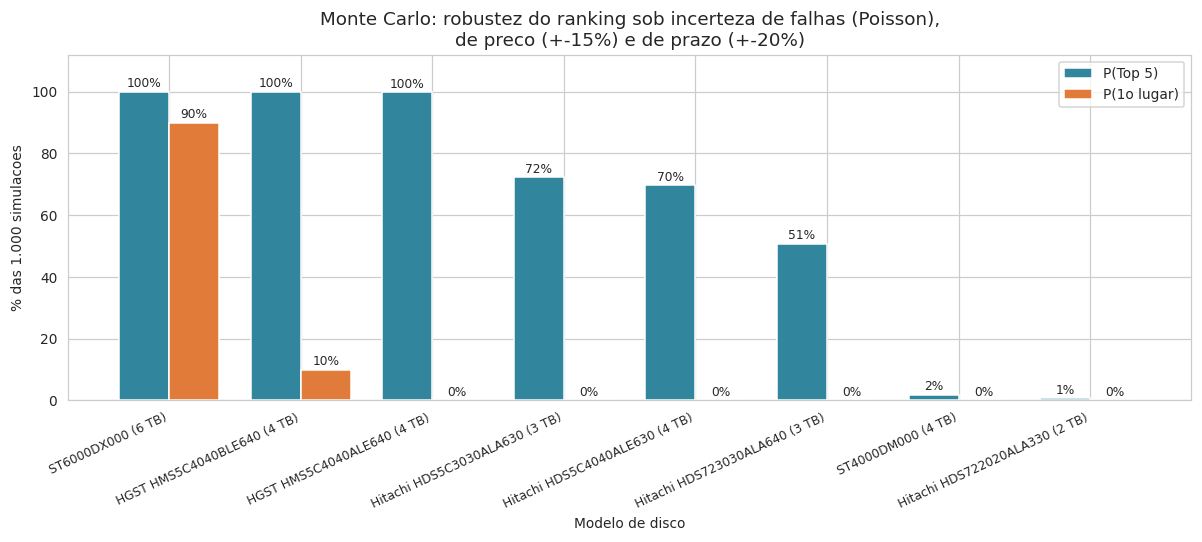

 posicao                   model  score_decisao  prob_top5_mc_%  prob_1o_mc_%
       1             ST6000DX000      97.509234           100.0          90.0
       2    HGST HMS5C4040BLE640      93.228557           100.0           9.9
       3    HGST HMS5C4040ALE640      88.277311            99.9           0.1
       4 Hitachi HDS5C3030ALA630      75.758894            72.2           0.0
       5 Hitachi HDS5C4040ALE630      75.414426            69.8           0.0
       6 Hitachi HDS723030ALA640      73.456386            50.7           0.0
       7             ST4000DM000      63.831886             1.8           0.0
       8 Hitachi HDS722020ALA330      61.241580             0.6           0.0


In [26]:
np.random.seed(RANDOM_STATE)
N_SIM = 1_000
base_mc = mcda.copy()
cont_top5_mc = np.zeros(len(base_mc)); cont_1o_mc = np.zeros(len(base_mc))

falhas_obs  = base_mc.falhas.values.astype(float)
disco_dias  = base_mc.disco_dias.values.astype(float)
fabricantes = base_mc.fabricante.values
cap         = base_mc.capacidade_tb.values
n_discos    = base_mc.n_discos.values
n_chassis   = base_mc.n_chassis.values
capex_chas  = base_mc.capex_chassi_usd.values
opex_ener   = base_mc.opex_energia_usd.values
risco_ml_n  = base_mc.risco_ml.values
risco_id_n  = base_mc.risco_idade.values
w = np.array([PESOS_MCDA['risco'], PESOS_MCDA['custo'], PESOS_MCDA['tempo']])

def mm(v):
    rng = v.max() - v.min()
    return (v - v.min()) / rng if rng > 0 else np.zeros_like(v)

for _ in range(N_SIM):
    # 1) AFR reamostrado por Poisson
    afr_sim = np.random.poisson(falhas_obs) / disco_dias * 365 * 100
    risco_sim = 100 * (PESOS_RISCO['afr'] * mm(afr_sim) +
                       PESOS_RISCO['ml'] * risco_ml_n +
                       PESOS_RISCO['idade'] * risco_id_n)
    # 2) preco por TB perturbado (+-15% lognormal)
    p_tb = np.array([USD_POR_TB[f] for f in fabricantes]) * np.random.lognormal(0, 0.15, len(base_mc))
    preco_disco = PRECO_BASE_DISCO_USD + cap * p_tb
    custo_sim = (n_discos * preco_disco + capex_chas +
                 n_discos * (afr_sim / 100) * HORIZONTE_ANOS * preco_disco * FATOR_MAO_DE_OBRA +
                 opex_ener)
    # 3) lead time perturbado (+-20% normal)
    lead = np.array([LEAD_TIME_SEMANAS[f] for f in fabricantes]) * np.clip(
        np.random.normal(1, 0.20, len(base_mc)), 0.5, 2.0)
    tempo_sim = (lead + SEMANAS_POR_CHASSI * n_chassis +
                 BURN_IN_BASE * (1 + BURN_IN_FATOR_RISCO * risco_sim / 100))

    s = 100 * (1 - (w[0] * mm(risco_sim) + w[1] * mm(custo_sim) + w[2] * mm(tempo_sim)))
    ordem = np.argsort(-s)
    cont_top5_mc[ordem[:5]] += 1
    cont_1o_mc[ordem[0]] += 1

mcda['prob_top5_mc_%'] = 100 * cont_top5_mc / N_SIM
mcda['prob_1o_mc_%']   = 100 * cont_1o_mc / N_SIM

d = mcda.head(8)
rot = [f'{m} ({c:g} TB)' for m, c in zip(d.model, d.capacidade_tb)]
x = np.arange(len(d)); larg = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - larg/2, d['prob_top5_mc_%'], larg, label='P(Top 5)', color='#31859c')
ax.bar(x + larg/2, d['prob_1o_mc_%'],  larg, label='P(1o lugar)', color='#e07b39')
ax.set_xticks(x); ax.set_xticklabels(rot, rotation=25, ha='right', fontsize=8)
ax.set_ylabel('% das 1.000 simulacoes')
ax.set_xlabel('Modelo de disco')
ax.set_title('Monte Carlo: robustez do ranking sob incerteza de falhas (Poisson),\n'
             'de preco (+-15%) e de prazo (+-20%)', fontsize=12)
ax.legend()
for i, (a, b) in enumerate(zip(d['prob_top5_mc_%'], d['prob_1o_mc_%'])):
    ax.text(i - larg/2, a + 1.5, f'{a:.0f}%', ha='center', fontsize=8)
    ax.text(i + larg/2, b + 1.5, f'{b:.0f}%', ha='center', fontsize=8)
ax.set_ylim(0, 112)
plt.tight_layout()
plt.show()

print(mcda.head(8)[['posicao', 'model', 'score_decisao',
                    'prob_top5_mc_%', 'prob_1o_mc_%']].to_string(index=False))

**Leitura do Monte Carlo.** Esta é a prova mais dura a que a recomendação é submetida, porque aqui os **próprios dados** são questionados, não apenas os pesos.

- O **`ST6000DX000` permanece em 1º lugar em 90%** das 1.000 simulações e no Top 5 em **100%** delas.
- O **`HGST HMS5C4040BLE640`** fica com os **9,9%** restantes.
- A partir da 4ª posição a estabilidade despenca: o `Hitachi HDS5C3030ALA630` cai para **72,2%** de probabilidade de Top 5 e o `ST4000DM000`, para **1,8%**.

**Por que a liderança sobrevive à reamostragem de Poisson.** Mesmo quando a simulação sorteia falhas que não ocorreram para o vencedor, ele mantém a vantagem estrutural de densidade (6 TB) que reduz custo e prazo. Já o `ST4000DM000`, que tinha score de caso-base 63,8, praticamente desaparece do Top 5 sob incerteza — porque seus 198 falhas observadas geram, ao serem reamostradas, cenários ainda piores com frequência suficiente para derrubá-lo.

**A leitura executiva honesta é esta:** existe cerca de **10% de probabilidade de o HGST ser, na verdade, a escolha melhor** sob as incertezas modeladas. Isso não invalida a recomendação — mas é a informação que justifica uma decisão de *hedge*: se a organização for construir mais de uma unidade, ou se o AFR real do `ST6000DX000` se deteriorar nos trimestres seguintes, o `HGST HMS5C4040BLE640` é a alternativa já validada e pronta para assumir.

## 10. Recomendação Final

In [27]:
m = mcda.iloc[0]
L = 78
print('=' * L)
print('RECOMENDACAO PARA A NOVA UNIDADE DE ARMAZENAMENTO EM NUVEM'.center(L))
print('=' * L)
print(f'  Modelo de disco recomendado ..... {m.model}')
print(f'  Fabricante ...................... {m.fabricante}')
print(f'  Capacidade unitaria ............. {m.capacidade_tb:g} TB')
print('-' * L)
print('  DIMENSAO 1 - RISCO (dados reais de campo)')
print(f'    AFR observado ................. {m["afr_%"]:.2f}%  '
      f'(IC 95%: {m["afr_ic_inf_%"]:.2f}% - {m["afr_ic_sup_%"]:.2f}%)')
print(f'    Evidencia ..................... {int(m.falhas)} falhas em {m.disco_dias:,.0f} disco-dias')
print(f'    Prob. media de pre-falha (RF) . {m.prob_ml:.4f}')
print(f'    Score de risco composto ....... {m.score_risco:.1f} / 100')
print('-' * L)
print(f'  DIMENSAO 2 - CUSTO (horizonte de {HORIZONTE_ANOS} anos, {CAPACIDADE_ALVO_TB:,} TB uteis)')
print(f'    Discos necessarios ............ {m.n_discos:,.0f}  ({m.n_chassis:,.0f} chassis)')
print(f'    CapEx (discos + chassis) ...... US$ {m.capex_discos_usd + m.capex_chassi_usd:,.0f}')
print(f'    OpEx reposicao ({HORIZONTE_ANOS} anos) ....... US$ {m.opex_reposicao_usd:,.0f}  '
      f'(~{m.discos_repostos_5a:,.0f} discos)')
print(f'    OpEx energia ({HORIZONTE_ANOS} anos) ......... US$ {m.opex_energia_usd:,.0f}')
print(f'    CUSTO TOTAL ................... US$ {m.custo_total_usd:,.0f}')
print(f'    Custo por TB util ............. US$ {m.custo_por_tb_util:,.2f}/TB')
print('-' * L)
print('  DIMENSAO 3 - TEMPO')
print(f'    Aquisicao ..................... {m.t_aquisicao:.1f} semanas')
print(f'    Instalacao .................... {m.t_instalacao:.1f} semanas')
print(f'    Burn-in (ajustado por risco) .. {m.t_burn_in:.1f} semanas')
print(f'    TEMPO TOTAL ................... {m.tempo_total_semanas:.1f} semanas '
      f'(~{m.tempo_total_meses:.1f} meses)')
print('-' * L)
print('  DECISAO')
print(f'    Score MCDA .................... {m.score_decisao:.1f} / 100')
print(f'    Estabilidade a pesos (Top 5) .. {m["estab_top5_pesos_%"]:.0f}% dos sorteios')
print(f'    Estabilidade a pesos (1o) ..... {m["estab_1o_pesos_%"]:.0f}% dos sorteios')
print(f'    Monte Carlo P(Top 5) .......... {m["prob_top5_mc_%"]:.0f}%')
print(f'    Monte Carlo P(1o lugar) ....... {m["prob_1o_mc_%"]:.0f}%')
print('=' * L)

          RECOMENDACAO PARA A NOVA UNIDADE DE ARMAZENAMENTO EM NUVEM          
  Modelo de disco recomendado ..... ST6000DX000
  Fabricante ...................... Seagate
  Capacidade unitaria ............. 6 TB
------------------------------------------------------------------------------
  DIMENSAO 1 - RISCO (dados reais de campo)
    AFR observado ................. 0.00%  (IC 95%: 0.00% - 0.80%)
    Evidencia ..................... 0 falhas em 167,498 disco-dias
    Prob. media de pre-falha (RF) . 0.0683
    Score de risco composto ....... 8.1 / 100
------------------------------------------------------------------------------
  DIMENSAO 2 - CUSTO (horizonte de 5 anos, 5,000 TB uteis)
    Discos necessarios ............ 981  (17 chassis)
    CapEx (discos + chassis) ...... US$ 218,093
    OpEx reposicao (5 anos) ....... US$ 0  (~0 discos)
    OpEx energia (5 anos) ......... US$ 45,116
    CUSTO TOTAL ................... US$ 263,209
    Custo por TB util ............. US$ 52.64/TB
---

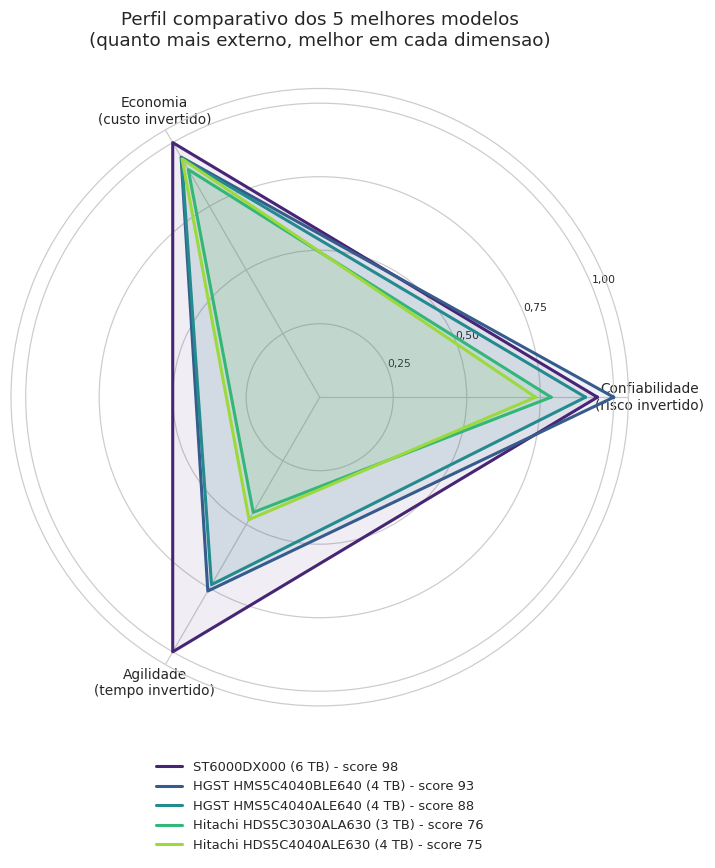

In [28]:
top5 = mcda.head(5)
categorias = ['Confiabilidade\n(risco invertido)', 'Economia\n(custo invertido)',
              'Agilidade\n(tempo invertido)']
angulos = np.linspace(0, 2 * np.pi, len(categorias), endpoint=False).tolist()
angulos += angulos[:1]

fig = plt.figure(figsize=(8.5, 8))
ax = plt.subplot(111, polar=True)
cores = plt.cm.viridis(np.linspace(0.1, 0.85, len(top5)))

for (_, r), cor in zip(top5.iterrows(), cores):
    vals = [1 - r.risco_norm, 1 - r.custo_norm, 1 - r.tempo_norm]
    vals += vals[:1]
    ax.plot(angulos, vals, lw=2, color=cor,
            label=f'{r.model} ({r.capacidade_tb:g} TB) - score {r.score_decisao:.0f}')
    ax.fill(angulos, vals, alpha=0.08, color=cor)

ax.set_xticks(angulos[:-1]); ax.set_xticklabels(categorias, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_yticks([0.25, 0.5, 0.75, 1.0]); ax.set_yticklabels(['0,25', '0,50', '0,75', '1,00'], fontsize=7)
ax.set_title('Perfil comparativo dos 5 melhores modelos\n(quanto mais externo, melhor em cada dimensao)',
             pad=28, fontsize=12)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.07), fontsize=8.5, frameon=False)
plt.tight_layout()
plt.show()

**Leitura do radar.** O gráfico expõe visualmente a geometria da decisão. Note que os eixos foram **invertidos** — mais externo é sempre melhor.

O **`ST6000DX000`** desenha o polígono mais próximo do máximo nos três vértices simultaneamente: é a única configuração sem um lado fraco. O **`HGST HMS5C4040BLE640`** o supera ligeiramente no eixo de confiabilidade, mas recua visivelmente em economia e agilidade — exatamente o trade-off de densidade discutido acima.

Os três modelos Hitachi formam polígonos visivelmente menores e **achatados na direção da agilidade**, consequência direta da premissa de 8 semanas de *lead time*. Se essa premissa estiver errada — e ela é uma estimativa de mercado, não um dado da base — a posição relativa deles melhora. Esse é o tipo de sensibilidade que vale verificar antes de fechar uma compra real, alterando o dicionário `LEAD_TIME_SEMANAS` na Seção 8 e reexecutando o notebook.

A forma do polígono é, no fim, mais informativa que o score único: **um modelo com área média e formato equilibrado é preferível a um de área parecida mas com um vértice colapsado**, porque o vértice colapsado é o que vira problema operacional real.

## 11. Exportação dos Resultados

In [29]:
COLS_EXPORT = ['posicao', 'model', 'fabricante', 'capacidade_tb', 'disco_dias', 'falhas',
               'afr_%', 'afr_ic_inf_%', 'afr_ic_sup_%', 'prob_ml', 'score_risco',
               'n_discos', 'n_chassis', 'custo_total_usd', 'custo_por_tb_util',
               'tempo_total_semanas', 'score_decisao',
               'estab_top5_pesos_%', 'estab_1o_pesos_%', 'prob_top5_mc_%', 'prob_1o_mc_%']

mcda[COLS_EXPORT].to_csv('ranking_mcda_discos_backblaze.csv', index=False,
                         float_format='%.4f', encoding='utf-8-sig')
df_afr.to_csv('afr_por_modelo_backblaze_2016q1.csv', index=False, encoding='utf-8-sig')

m = mcda.iloc[0]
resumo = f'''RESUMO EXECUTIVO - MVP RISCO x CUSTO x TEMPO
Nova unidade de armazenamento em nuvem | Disciplina: Sistemas de Suporte a Decisao

BASE: Backblaze Hard Drive Stats - 1o trimestre de 2016 (dados reais de operacao)
  Dias processados ....... {len(dias_ok)}
  Disco-dias analisados .. {df_modelos.disco_dias.sum():,}
  Falhas observadas ...... {df_modelos.falhas.sum():,}
  Modelos avaliados ...... {len(mcda)} (com >= {MIN_DISCO_DIAS:,} disco-dias)

RECOMENDACAO: {m.model} ({m.fabricante}, {m.capacidade_tb:g} TB)
  Score MCDA ............. {m.score_decisao:.1f}/100
  AFR observado .......... {m["afr_%"]:.2f}% (IC95: {m["afr_ic_inf_%"]:.2f}-{m["afr_ic_sup_%"]:.2f}%)
  Custo total 5 anos ..... US$ {m.custo_total_usd:,.0f} para {CAPACIDADE_ALVO_TB:,} TB uteis
  Custo por TB util ...... US$ {m.custo_por_tb_util:,.2f}
  Tempo de implantacao ... {m.tempo_total_semanas:.1f} semanas (~{m.tempo_total_meses:.1f} meses)
  Discos necessarios ..... {m.n_discos:,.0f} em {m.n_chassis:,.0f} chassis

ROBUSTEZ
  Sensibilidade a pesos ... aparece no Top 5 em {m["estab_top5_pesos_%"]:.0f}% de 1.000 sorteios
  Monte Carlo ............. P(Top 5) = {m["prob_top5_mc_%"]:.0f}% | P(1o) = {m["prob_1o_mc_%"]:.0f}%

MODELO DE RISCO (Random Forest sobre S.M.A.R.T. reais)
  ROC-AUC ................ {auc:.4f}
  PR-AUC ................. {ap:.4f} (base aleatoria {base_rand:.4f})

PREMISSAS NAO DERIVADAS DA BASE (estimativas de mercado)
  US$/TB por fabricante, custo de chassi, preco de energia, PUE,
  lead time de aquisicao, tempo de instalacao e de burn-in.
'''

with open('resumo_executivo_mvp.txt', 'w', encoding='utf-8') as f:
    f.write(resumo)

print('Arquivos gerados no diretorio de trabalho:')
for arq in ['ranking_mcda_discos_backblaze.csv', 'afr_por_modelo_backblaze_2016q1.csv',
            'resumo_executivo_mvp.txt']:
    print(f'  {arq:45s} {os.path.getsize(arq):>8,} bytes')
print('\n' + resumo)

Arquivos gerados no diretorio de trabalho:
  ranking_mcda_discos_backblaze.csv                2,080 bytes
  afr_por_modelo_backblaze_2016q1.csv              1,154 bytes
  resumo_executivo_mvp.txt                         1,160 bytes

RESUMO EXECUTIVO - MVP RISCO x CUSTO x TEMPO
Nova unidade de armazenamento em nuvem | Disciplina: Sistemas de Suporte a Decisao

BASE: Backblaze Hard Drive Stats - 1o trimestre de 2016 (dados reais de operacao)
  Dias processados ....... 89
  Disco-dias analisados .. 5,314,565
  Falhas observadas ...... 278
  Modelos avaliados ...... 11 (com >= 40,050 disco-dias)

RECOMENDACAO: ST6000DX000 (Seagate, 6 TB)
  Score MCDA ............. 97.5/100
  AFR observado .......... 0.00% (IC95: 0.00-0.80%)
  Custo total 5 anos ..... US$ 263,209 para 5,000 TB uteis
  Custo por TB util ...... US$ 52.64
  Tempo de implantacao ... 7.1 semanas (~1.6 meses)
  Discos necessarios ..... 981 em 17 chassis

ROBUSTEZ
  Sensibilidade a pesos ... aparece no Top 5 em 100% de 1.000 sorte

## 12. Conclusões e Limitações

### 12.1 Recomendação

Para a nova unidade de 5 PB, o modelo recomendado é o **`ST6000DX000` (Seagate, 6 TB)**, com score MCDA de **97,5/100**:

- **Risco:** 0 falhas em 167.498 disco-dias (AFR observado 0,00%, com teto de 0,80% no IC 95%)
- **Custo:** US$ 263.209 em 5 anos para 5.000 TB úteis — US$ 52,64 por TB útil
- **Tempo:** 7,1 semanas até entrar em produção (~1,6 mês), com 981 discos em 17 chassis
- **Robustez:** vence em 94% dos cenários de pesos e em 90% das simulações de Monte Carlo

A **alternativa de contingência** é o **`HGST HMS5C4040BLE640`**, que na verdade tem a evidência de confiabilidade *mais forte* do estudo (0 falhas em 275.099 disco-dias) e perde apenas por densidade — seus 4 TB exigem 50% mais discos, o que custa US$ 100 mil e 2,3 semanas a mais.

### 12.2 Principais achados

1. **A escolha do modelo de disco importa muito.** Entre os 11 modelos avaliados, o AFR variou de **0,00% a 4,48%** e o custo total de 5 anos, de **US$ 263 mil a US$ 2,0 milhões** para a mesma capacidade útil.
2. **Risco se converte em dinheiro de forma mensurável.** Dois modelos de 6 TB com a mesma densidade diferem em **US$ 53 mil (+20%)** no horizonte de 5 anos, quase inteiramente por causa do AFR.
3. **O disco mais barato por TB não foi o mais barato no total.** O `ST4000DM000` tem CapEx US$ 24 mil menor que o HGST equivalente, mas seus US$ 25 mil de reposição anulam a vantagem.
4. **Setor pendente (`smart_197`) é o melhor preditor individual de falha** (ρ = 0,485), acima de setores realocados (0,178). Realocar é o disco resolvendo o problema; ter pendências é o disco não conseguindo mais resolver.
5. **Temperatura praticamente não prediz falha** (ρ = −0,018) dentro da faixa operacional de um data center — reproduzindo um achado já publicado pela própria Backblaze.
6. **Cerca de 70% dos discos que falham não emitem sinal prévio de setor pendente.** Predição por S.M.A.R.T. é um complemento útil (ROC-AUC 0,805; 45% de recall), **nunca um substituto da redundância**.
7. **Densidade domina custo e prazo.** O número de discos — e não os terabytes — é o que puxa chassis, energia e tempo de instalação.

### 12.3 Limitações (leitura obrigatória antes de usar estes números)

**Sobre a base de dados:**

- Os dados são **reais, mas de janeiro a março de 2016**. Os modelos analisados estão hoje descontinuados e as tecnologias mudaram (hoje há discos de 20+ TB, SMR, HAMR). A **metodologia** é transferível para o trimestre mais recente apenas alterando `DATA_INICIO`/`DATA_FIM`; os **números específicos**, não.
- **Dois dias faltaram** no espelho (04 e 05/01/2016), de 91 dias solicitados. Como a análise é baseada em taxas por disco-dia, o impacto é desprezível, mas está registrado.
- **Um trimestre é uma janela curta para eventos raros.** Dois modelos registraram zero falhas — o que claramente não significa AFR real igual a zero. Foi por isso que usamos intervalos de Poisson em vez de estimativas pontuais, mas o problema de fundo permanece.
- **Viés de truncamento à esquerda.** Observamos discos já em operação, não coortes desde a instalação. A mortalidade infantil (falhas nas primeiras semanas) está sub-representada — justamente o que o burn-in deveria capturar.
- **Viés de composição da frota.** A Backblaze operava predominantemente discos de linha *consumer* em um ambiente específico. O AFR de um modelo aqui não é necessariamente o AFR dele em outro data center.

**Sobre os modelos de Custo e Tempo:**

- ⚠️ **Estes dois eixos NÃO vêm da base.** Preço por TB, custo de chassi, preço da energia, PUE, *lead time*, tempo de instalação e de burn-in são **premissas de mercado assumidas por mim**, documentadas nas tabelas das Seções 7 e 8. Elas são plausíveis e parametrizadas, mas não são dados verificados. Apenas o eixo de Risco é empírico.
- O modelo de custo **cobre só a camada que depende do disco** (discos, chassis, reposição, energia). Prédio, rede, racks, refrigeração e pessoal ficam de fora — eles existem, mas seriam praticamente iguais para qualquer modelo e não mudariam o ranking.
- A premissa de 8 semanas de *lead time* para Hitachi penaliza fortemente três dos 11 modelos. Ela é defensável (linha em descontinuação em 2016), mas é uma premissa, e o radar da Seção 10 mostra que é ela que achata o perfil desses modelos.

**Sobre a modelagem:**

- A **janela de 7 dias** para definir "pré-falha" é uma escolha de projeto. Janelas maiores aumentariam o número de positivos mas diluiriam o sinal.
- A **normalização min-max** é sensível a valores extremos: o `ST500LM012 HN`, com custo 8× maior que o segundo colocado, comprime toda a escala de custo dos demais modelos. Uma alternativa seria normalizar por z-score ou excluir outliers antes.
- Os **pesos da MCDA e do score de risco são decisões gerenciais**, não estatísticas. A Seção 9.1 mostra que a recomendação sobrevive a variações neles — mas essa verificação é sobre *estabilidade*, não sobre os pesos estarem "certos".
- A **MCDA favorece estruturalmente discos de maior capacidade**, porque densidade reduz custo e prazo simultaneamente. Isso é um efeito real, não um artefato — mas significa que, se um modelo de altíssima capacidade tivesse entrado no conjunto, provavelmente venceria mesmo com risco pior.

### 12.4 Próximos passos sugeridos

1. **Reexecutar com o trimestre mais recente** disponível, para decidir sobre modelos que ainda estão à venda.
2. **Substituir as premissas de custo e prazo por cotações reais** de fornecedores — é a mudança que mais aumentaria a confiabilidade do resultado, já que dois dos três eixos hoje são estimados.
3. **Estender a janela de risco para 4 a 8 trimestres**, o que estreitaria drasticamente os intervalos de confiança e permitiria distinguir com segurança modelos hoje empatados em "zero falhas".
4. **Modelar a curva de sobrevivência** (Kaplan-Meier) por modelo, em vez de uma taxa média única, capturando a curva de banheira (mortalidade infantil e desgaste terminal) que o AFR agregado esconde.